# EDA: ChEMBL MIC, DrugBank, CARD

## Configuration

In [1]:
import sys
import json
import sqlite3
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem, RDLogger
from rapidfuzz import fuzz
from sklearn.metrics import roc_auc_score

from rdkit.Chem import Descriptors

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from config import ProjectConfig
from src.feature_engineering import (
    bemis_murcko_scaffold, lipinski_descriptors, morgan_fingerprint,
    pool_map, scaffold_fold_labels,
)

RDLogger.DisableLog("rdApp.*")

cfg = ProjectConfig()
RAW = cfg.paths.raw
PROCESSED = cfg.paths.processed
PLOTS = cfg.paths.eda_plots
PROCESSED.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MIC_THRESHOLD = cfg.data.mic_threshold
FP_BITS = 2048
SEED = cfg.train.seed
N_WORKERS = cfg.train.num_workers

sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 150})

assert RAW.exists(), "raw data folder missing under Datasets/raw"
print(f"workers: {N_WORKERS}")


workers: 8


## Stat helpers

In [2]:
def activity_tiers(mic_values):
    """Bin MIC values into four ordered activity classes."""
    return pd.cut(
        mic_values,
        bins=[0, 1, MIC_THRESHOLD, 100, np.inf],
        labels=["Highly Active", "Active", "Moderate", "Inactive"],
        right=False,
    )


def lipinski_pass(df):
    """Vectorized Lipinski compliance flag (>= 3 of 4 rules)."""
    return (
        (df["molecular_weight"] <= 500).astype(int)
        + (df["logp"] <= 5).astype(int)
        + (df["h_bond_donors"] <= 5).astype(int)
        + (df["h_bond_acceptors"] <= 10).astype(int)
    ) >= 3


def active_frac(mic_values, threshold=MIC_THRESHOLD):
    """Fraction of MIC values strictly below the activity threshold."""
    vals = pd.to_numeric(pd.Series(mic_values), errors="coerce").dropna()
    if vals.empty:
        return 0.0
    return float((vals < threshold).mean())


def descriptor_table(unique_smiles):
    """Lipinski descriptor DataFrame indexed by canonical SMILES."""
    valid = unique_smiles.map(lipinski_descriptors).dropna()
    df = pd.DataFrame(valid.tolist())
    df.index = unique_smiles.loc[valid.index].values
    return df


def scaffolds(smiles_iterable):
    """Bemis-Murcko scaffolds aligned with input order."""
    items = list(smiles_iterable)
    return pd.Series(pool_map(bemis_murcko_scaffold, items, N_WORKERS))


def scaffold_set(smiles_series):
    """Unique non-empty Bemis-Murcko scaffolds; ringless molecules have
    no scaffold and are excluded from leakage checks."""
    scaf = scaffolds(smiles_series).dropna()
    return set(scaf[scaf != ""].unique())


def joint_folds(frames, seed=SEED):
    """Canonical SMILES to train/val/test fold under the production joint
    scaffold split shared across organisms."""
    smiles = pd.concat([f["canonical_smiles"] for f in frames])
    return scaffold_fold_labels(smiles, cfg.data.train_frac,
                                cfg.data.val_frac, seed)


def borderline_fraction(mic_values, threshold=MIC_THRESHOLD, factor=2.0):
    """Fraction of MIC values within a fold window of the threshold."""
    vals = pd.to_numeric(pd.Series(mic_values), errors="coerce").dropna()
    if vals.empty:
        return 0.0
    lo, hi = threshold / factor, threshold * factor
    return float(((vals >= lo) & (vals <= hi)).mean())


def log_replicate_variance(df, smiles_col, mic_col):
    """Replicate variance computed on log10(MIC), the natural MIC scale."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    if clean.empty:
        return pd.DataFrame()
    clean["log_mic"] = np.log10(clean[mic_col])
    stats = (clean.groupby(smiles_col)["log_mic"]
             .agg(["count", "mean", "std"]))
    multi = stats[stats["count"] > 1].copy()
    if multi.empty:
        return multi
    multi["cv"] = multi["std"] / multi["mean"].abs().clip(lower=1e-12)
    return multi


def aggregated_actives(df, smiles_col="canonical_smiles",
                       mic_col="mic_value", threshold=MIC_THRESHOLD):
    """Active rate after median-log-MIC aggregation per compound."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    agg = clean.groupby(smiles_col)["log_mic"].median()
    return float((agg < np.log10(threshold)).mean()), len(agg)


def label_flips(df, smiles_col="canonical_smiles",
                mic_col="mic_value", threshold=MIC_THRESHOLD):
    """Compounds where replicates disagree on active/inactive at threshold."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["active"] = clean[mic_col] < threshold
    counts = clean.groupby(smiles_col)["active"].agg(["sum", "size"])
    multi = counts[counts["size"] > 1]
    if multi.empty:
        return 0, 0
    flips = ((multi["sum"] > 0) & (multi["sum"] < multi["size"])).sum()
    return int(flips), len(multi)


def label_flip_by_distance(df, smiles_col="canonical_smiles",
                           mic_col="mic_value", threshold=MIC_THRESHOLD):
    """Label-flip rate per distance-from-threshold bin (replicates only)."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    clean["active"] = clean[mic_col] < threshold
    grp = clean.groupby(smiles_col).agg(
        size=("active", "size"),
        actives=("active", "sum"),
        median_log=("log_mic", "median"))
    multi = grp[grp["size"] > 1].copy()
    if multi.empty:
        return pd.DataFrame()
    multi["flips"] = (multi["actives"] > 0) & (multi["actives"] < multi["size"])
    multi["dist"] = (multi["median_log"] - np.log10(threshold)).abs()
    multi["bin"] = pd.cut(
        multi["dist"], bins=[0, 0.3, 0.6, 1.0, 2.0, np.inf],
        labels=["<0.3 (~2x)", "0.3-0.6", "0.6-1.0", "1.0-2.0", ">2.0"])
    return (multi.groupby("bin", observed=True)
            .agg(n_compounds=("flips", "size"),
                 n_flips=("flips", "sum")))


def noise_by_threshold_distance(df, smiles_col, mic_col,
                                threshold=MIC_THRESHOLD):
    """Per-compound log-MIC std bucketed by distance from log10(threshold)."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    stats = (clean.groupby(smiles_col)["log_mic"]
             .agg(["count", "median", "std"]))
    multi = stats[stats["count"] > 1].copy()
    if multi.empty:
        return multi
    multi["dist"] = (multi["median"] - np.log10(threshold)).abs()
    multi["bin"] = pd.cut(
        multi["dist"], bins=[0, 0.3, 0.6, 1.0, 2.0, np.inf],
        labels=["<0.3 (~2x)", "0.3-0.6", "0.6-1.0", "1.0-2.0", ">2.0"])
    return multi


def mw_activity_bins(mic, mw, edges, threshold=MIC_THRESHOLD):
    """Active fraction and count per molecular weight bin."""
    df = pd.DataFrame({"mic": pd.to_numeric(mic, errors="coerce"),
                       "mw":  pd.to_numeric(mw,  errors="coerce")}).dropna()
    if df.empty:
        return pd.DataFrame()
    df["active"] = df["mic"] < threshold
    df["bin"] = pd.cut(df["mw"], edges, include_lowest=True)
    return (df.groupby("bin", observed=True)["active"]
            .agg(["mean", "size"])
            .rename(columns={"mean": "active_rate", "size": "n"}))


def top_actives(df, smiles_col="canonical_smiles",
                mic_col="mic_value", n=5):
    """N compounds with the lowest MIC, deduplicated by canonical SMILES."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0]
    if clean.empty:
        return pd.DataFrame()
    return (clean.groupby(smiles_col)[mic_col]
            .min().nsmallest(n).reset_index())


## Fingerprint helpers

In [3]:
def fingerprint_matrix(smiles_iterable):
    """Dense uint8 Morgan fingerprint matrix; zero rows for parse failures."""
    items = list(smiles_iterable)
    if not items:
        return np.zeros((0, FP_BITS), dtype=np.uint8)
    rows = pool_map(morgan_fingerprint, items, N_WORKERS)
    zero = np.zeros(FP_BITS, dtype=np.uint8)
    return np.vstack([
        (r.astype(np.uint8) if r is not None else zero) for r in rows
    ])


def nearest_similarity(query_fps, reference_fps, chunk=512):
    """Max Tanimoto from each query row to any reference row."""
    if len(query_fps) == 0 or len(reference_fps) == 0:
        return np.zeros(len(query_fps), dtype=np.float32)
    b = reference_fps.astype(np.float32)
    b_sum = b.sum(axis=1)
    out = np.empty(len(query_fps), dtype=np.float32)
    for i in range(0, len(query_fps), chunk):
        a = query_fps[i:i + chunk].astype(np.float32)
        inter = a @ b.T
        union = a.sum(axis=1, keepdims=True) + b_sum - inter
        out[i:i + chunk] = (inter / np.maximum(union, 1.0)).max(axis=1)
    return out


def fold_unique_fps(df, fold_indices, smiles_col="canonical_smiles"):
    """Fingerprint matrix for unique SMILES in a positional-index fold."""
    return fingerprint_matrix(
        df[smiles_col].iloc[fold_indices].dropna().unique())


def coverage_stats(label, query_fps, reference_fps):
    """Coverage statistics for queries against a reference fingerprint set."""
    sim = nearest_similarity(query_fps, reference_fps)
    if len(sim) == 0:
        print(f"  {label}: empty")
        return sim
    print(f"  {label}: n={len(sim):,}  "
          f">=0.4: {(sim >= 0.4).mean():.1%}  "
          f">=0.6: {(sim >= 0.6).mean():.1%}  "
          f"~identical: {(sim >= 0.99).mean():.1%}  "
          f"median: {float(np.median(sim)):.3f}")
    return sim


## Plotting helpers

In [4]:
def mic_histogram(df, organism, save_path):
    """Log10 MIC distribution with activity threshold marker."""
    vals = df.loc[df["mic_value"] > 0, "mic_value"]
    if vals.empty:
        return
    fig, ax = plt.subplots()
    ax.hist(np.log10(vals), bins=50, edgecolor="black")
    ax.axvline(np.log10(MIC_THRESHOLD), color="red", ls="--",
               label=f"Threshold ({MIC_THRESHOLD})")
    ax.set(xlabel="log10(MIC) [ug/mL]", ylabel="Frequency",
           title=f"MIC Distribution - {organism}")
    ax.legend()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def lipinski_panel(df, save_path, title=""):
    """2x2 Lipinski property histograms with rule-of-5 limits."""
    fields = [("molecular_weight", 500, "Molecular Weight"),
              ("logp", 5, "LogP"),
              ("h_bond_donors", 5, "H-bond Donors"),
              ("h_bond_acceptors", 10, "H-bond Acceptors")]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    if title:
        fig.suptitle(title)
    for ax, (col, limit, label) in zip(axes.flat, fields):
        ax.hist(df[col].dropna(), bins=30, edgecolor="black")
        ax.axvline(limit, color="red", ls="--", label="Lipinski limit")
        ax.set(xlabel=label, ylabel="Frequency")
        ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def balance_bars(fracs, labels, save_path):
    """Active vs inactive fraction side-by-side bars."""
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - 0.15, fracs, 0.3, label="Active", edgecolor="black")
    ax.bar(x + 0.15, 1 - np.array(fracs), 0.3,
           label="Inactive", edgecolor="black")
    ax.set(xticks=x, ylabel="Fraction",
           title=f"Class Balance (MIC < {MIC_THRESHOLD})")
    ax.set_xticklabels(labels)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def mw_overlay(distributions, save_path, title="Molecular Weight"):
    """Overlay molecular weight histograms from labeled series."""
    fig, ax = plt.subplots()
    for label, vals in distributions.items():
        v = pd.to_numeric(pd.Series(vals), errors="coerce").dropna()
        if v.empty:
            continue
        ax.hist(v, bins=40, alpha=0.5, edgecolor="black",
                label=f"{label} (n={len(v):,})")
    ax.set(xlabel="Molecular Weight (Da)", ylabel="Frequency", title=title)
    ax.legend()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def similarity_density(values, save_path, title="Max Tanimoto"):
    """Histogram of similarity values with reference cutoff lines."""
    vals = np.asarray(values, dtype=np.float32)
    vals = vals[np.isfinite(vals)]
    fig, ax = plt.subplots()
    ax.hist(vals, bins=40, edgecolor="black")
    ax.axvline(0.4, color="orange", ls="--", label="0.4")
    ax.axvline(0.6, color="red", ls="--", label="0.6")
    ax.set(xlabel="Max Tanimoto similarity", ylabel="Frequency", title=title)
    ax.legend()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def similarity_overlay(named_arrays, save_path,
                       title="Test-vs-train similarity"):
    """Overlay similarity histograms for multiple labelled arrays."""
    fig, ax = plt.subplots()
    for label, vals in named_arrays.items():
        v = np.asarray(vals, dtype=np.float32)
        v = v[np.isfinite(v)]
        ax.hist(v, bins=40, alpha=0.5, edgecolor="black",
                label=f"{label} (n={len(v):,})")
    ax.axvline(0.4, color="orange", ls="--", label="0.4")
    ax.axvline(0.6, color="red", ls="--", label="0.6")
    ax.set(xlabel="Max Tanimoto similarity to training",
           ylabel="Frequency", title=title)
    ax.legend()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def length_histogram(smiles_series, save_path, title="SMILES Length"):
    """Histogram of SMILES character lengths."""
    lens = smiles_series.dropna().astype(str).str.len()
    if lens.empty:
        return
    fig, ax = plt.subplots()
    ax.hist(lens, bins=50, edgecolor="black")
    ax.set(xlabel="SMILES length (characters)",
           ylabel="Frequency", title=title)
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def activity_by_mw_chart(bin_stats, title, save_path):
    """Active rate per molecular weight bin with sample counts."""
    if bin_stats.empty:
        return
    labels = [str(b) for b in bin_stats.index]
    x = np.arange(len(bin_stats))
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x, bin_stats["active_rate"], edgecolor="black")
    for xi, (rate, n) in enumerate(zip(bin_stats["active_rate"],
                                        bin_stats["n"])):
        ax.text(xi, rate + 0.01, f"n={int(n):,}", ha="center", fontsize=8)
    ax.set(xticks=x, xlabel="Molecular Weight Bin (Da)",
           ylabel=f"Active Rate (MIC < {MIC_THRESHOLD})", title=title,
           ylim=(0, min(1.0, bin_stats["active_rate"].max() + 0.12)))
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def noise_distance_chart(stats, organism, save_path):
    """Median log-MIC std per distance-from-threshold bin."""
    if stats.empty:
        return
    by_bin = (stats.groupby("bin", observed=True)["std"]
              .agg(["median", "count"]))
    fig, ax = plt.subplots()
    x = np.arange(len(by_bin))
    ax.bar(x, by_bin["median"], edgecolor="black")
    for xi, (s, n) in enumerate(zip(by_bin["median"], by_bin["count"])):
        ax.text(xi, s + 0.005, f"n={int(n)}", ha="center", fontsize=8)
    ax.set(xticks=x, xlabel="|log10(MIC) - log10(threshold)|",
           ylabel="median per-compound log-MIC std",
           title=f"{organism}: replicate noise vs threshold distance")
    ax.set_xticklabels(by_bin.index, rotation=20, ha="right")
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


## CARD resistome catalog

In [5]:
def card_genes(card_dir):
    """Resistance gene entries from CARD JSON."""
    with open(card_dir / "card.json") as f:
        data = json.load(f)
    return {k: v for k, v in data.items() if k.isdigit()}


def card_categories(genes, class_name=None):
    """ARO subcategory value counts, optionally filtered by class name."""
    names = []
    for info in genes.values():
        aro = info.get("ARO_category", {})
        if not isinstance(aro, dict):
            continue
        for cat in aro.values():
            if not isinstance(cat, dict):
                continue
            if class_name and cat.get("category_aro_class_name") != class_name:
                continue
            name = cat.get("category_aro_name", "")
            if name:
                names.append(name)
    return pd.Series(names).value_counts()


genes = card_genes(RAW)
mechanisms = card_categories(genes, "AMR Gene Family")
drug_classes = card_categories(genes, "Drug Class")
class_names = {n.lower().strip() for n in drug_classes.index}

print(f"Resistance genes:    {len(genes):,}")
print(f"Unique mechanisms:   {len(mechanisms):,}")
print(f"Unique drug classes: {len(class_names)}")
print(f"\nTop 5 mechanisms:\n{mechanisms.head().to_string()}")
print(f"\nTop 5 drug classes:\n{drug_classes.head().to_string()}")


Resistance genes:    6,442
Unique mechanisms:   522
Unique drug classes: 46

Top 5 mechanisms:
OXA beta-lactamase                                                       1271
PDC beta-lactamase                                                        640
OXA-51-like beta-lactamase                                                383
ADC beta-lactamases pending classification for carbapenemase activity     274
CTX-M beta-lactamase                                                      267

Top 5 drug classes:
cephalosporin                 3404
penicillin beta-lactam        3115
carbapenem                    2572
monobactam                    1310
fluoroquinolone antibiotic     307


## ChEMBL MIC extraction

In [6]:
MIC_SQL = """
SELECT DISTINCT cs.canonical_smiles,
                md.chembl_id,
                act.standard_value AS mic_value,
                act.standard_units,
                td.organism
FROM compound_structures cs
JOIN molecule_dictionary md ON cs.molregno = md.molregno
JOIN activities act ON md.molregno = act.molregno
JOIN assays ass ON act.assay_id = ass.assay_id
JOIN target_dictionary td ON ass.tid = td.tid
WHERE td.organism LIKE ?
  AND act.standard_type = 'MIC'
  AND act.standard_units = 'ug.mL-1'
  AND act.standard_relation = '='
  AND cs.canonical_smiles IS NOT NULL
  AND act.standard_value IS NOT NULL
"""


def chembl_mic_data(organism, tag):
    """Per-organism MIC records: cached CSV first, ChEMBL DB on miss."""
    csv_path = PROCESSED / f"{tag}_mic_data.csv"
    if csv_path.exists():
        return pd.read_csv(csv_path)
    db = RAW / "chembl_33" / "chembl_33_sqlite" / "chembl_33.db"
    if not db.exists():
        raise FileNotFoundError(f"No cache at {csv_path}, no DB at {db}")
    conn = sqlite3.connect(str(db))
    df = pd.read_sql_query(MIC_SQL, conn, params=(f"%{organism}%",))
    conn.close()
    df.to_csv(csv_path, index=False)
    return df


df_sa = chembl_mic_data("Staphylococcus aureus", "staphylococcus_aureus")
df_ec = chembl_mic_data("Escherichia coli", "escherichia_coli")

print(f"S. aureus: {len(df_sa):,} records, "
      f"{df_sa['canonical_smiles'].nunique():,} unique")
print(f"E. coli:   {len(df_ec):,} records, "
      f"{df_ec['canonical_smiles'].nunique():,} unique")
print(f"Active rate: SA {active_frac(df_sa['mic_value']):.1%}, "
      f"EC {active_frac(df_ec['mic_value']):.1%}")
print(f"\nS. aureus activity tiers:")
print(activity_tiers(df_sa["mic_value"]).value_counts().to_string())


S. aureus: 68,511 records, 45,515 unique
E. coli:   44,131 records, 32,840 unique
Active rate: SA 52.4%, EC 38.3%

S. aureus activity tiers:
mic_value
Active           21355
Moderate         20876
Highly Active    14546
Inactive         11734


## Data sanity: MIC extremes and SMILES

In [7]:
def mic_extremes(df, mic_col="mic_value", n_show=5):
    """Percentiles plus rows with the most extreme log-MIC values."""
    vals = pd.to_numeric(df[mic_col], errors="coerce").dropna()
    vals = vals[vals > 0]
    log_vals = np.log10(vals)
    qs = vals.quantile([0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999])
    z = (log_vals - log_vals.mean()) / log_vals.std()
    extreme_idx = log_vals.iloc[z.abs().nlargest(n_show).index].index
    return {
        "n_total": len(vals),
        "percentiles": qs,
        "n_above_3sd": int((z > 3).sum()),
        "n_below_neg3sd": int((z < -3).sum()),
        "extreme_rows": df.loc[extreme_idx, ["canonical_smiles", mic_col]],
    }


def hygiene_summary(label, df, smiles_col="canonical_smiles"):
    """Salt fraction, parse-failure rate, stereo-marker presence."""
    smiles = df[smiles_col].dropna().drop_duplicates()
    n = len(smiles)
    if n == 0:
        print(f"  {label}: empty")
        return
    has_salt = smiles.str.contains(r"\.", regex=True, na=False)
    has_stereo = smiles.str.contains(r"[@/\\]", regex=True, na=False)
    parses = smiles.map(lambda s: Chem.MolFromSmiles(s) is not None)
    print(f"  {label}: n_unique={n:,}")
    print(f"    salts (contains '.'):     "
          f"{int(has_salt.sum()):>6,}  ({has_salt.mean():.1%})")
    print(f"    stereo markers (@,/,\\\\): "
          f"{int(has_stereo.sum()):>6,}  ({has_stereo.mean():.1%})")
    print(f"    parse failures:           "
          f"{int((~parses).sum()):>6,}  ({(~parses).mean():.1%})")


for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    ex = mic_extremes(df)
    print(f"\n{label}: n={ex['n_total']:,}")
    print("  MIC percentiles (ug/mL):")
    for p, v in ex["percentiles"].items():
        print(f"    {p:>6.1%}: {v:>12,.4f}")
    n = ex["n_total"]
    print(f"  Beyond +3 SD log-MIC: {ex['n_above_3sd']:,} "
          f"({ex['n_above_3sd'] / n:.2%})")
    print(f"  Beyond -3 SD log-MIC: {ex['n_below_neg3sd']:,} "
          f"({ex['n_below_neg3sd'] / n:.2%})")

print("\nSMILES hygiene:")
for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    hygiene_summary(label, df)



S. aureus: n=68,466
  MIC percentiles (ug/mL):
      0.1%:       0.0003
      1.0%:       0.0080
      5.0%:       0.0600
     50.0%:       8.0000
     95.0%:     256.0000
     99.0%:   1,000.0000
     99.9%:  69,885.0000
  Beyond +3 SD log-MIC: 148 (0.22%)
  Beyond -3 SD log-MIC: 219 (0.32%)

E. coli: n=44,115
  MIC percentiles (ug/mL):
      0.1%:       0.0010
      1.0%:       0.0080
      5.0%:       0.0600
     50.0%:      25.0000
     95.0%:     400.0000
     99.0%:   1,617.2000
     99.9%: 100,000.0000
  Beyond +3 SD log-MIC: 96 (0.22%)
  Beyond -3 SD log-MIC: 146 (0.33%)

SMILES hygiene:
  S. aureus: n_unique=45,515
    salts (contains '.'):      3,708  (8.1%)
    stereo markers (@,/,\\): 24,914  (54.7%)
    parse failures:                0  (0.0%)
  E. coli: n_unique=32,840
    salts (contains '.'):      3,034  (9.2%)
    stereo markers (@,/,\\): 16,386  (49.9%)
    parse failures:                0  (0.0%)


## DrugBank antibiotics and CARD substrate compounds

In [8]:
def drugbank_catalog(xml_path):
    """All drugs with SMILES from the DrugBank XML."""
    ns = {"db": "http://www.drugbank.ca"}
    root = ET.parse(str(xml_path)).getroot()
    drugs = []
    for drug in root.findall("db:drug", ns):
        smi = drug.find(
            './/db:calculated-properties/db:property'
            '[db:kind="SMILES"]/db:value', ns)
        drugs.append({
            "drugbank_id": drug.findtext(
                'db:drugbank-id[@primary="true"]', namespaces=ns),
            "name": drug.findtext("db:name", namespaces=ns),
            "smiles": smi.text if smi is not None else None,
            "categories": [c.text for c in drug.findall(
                ".//db:categories/db:category/db:category", ns)],
        })
    return drugs


def antibiotics(drugs):
    """DrugBank entries with antibacterial categorization."""
    keywords = {"antibacterial", "antibiotic", "anti-bacterial"}
    return [d for d in drugs if d["smiles"]
            and any(k in " ".join(d["categories"]).lower() for k in keywords)]


def tokenize(text):
    """Lowercase token set for fuzzy matching."""
    stop = {"antibiotic", "antibiotics", "agent", "agents", "and", "of", "the"}
    return {t for t in text.lower().replace("-", " ").replace(",", " ").split()
            if len(t) >= 3 and t not in stop}


def card_match(card_class, drugbank_text, threshold=90):
    """Token-overlap with fuzzy fallback between CARD and DrugBank text."""
    ct, dt = tokenize(card_class), tokenize(drugbank_text)
    for c in ct:
        if len(c) < 4:
            continue
        for d in dt:
            if c.startswith(d) or d.startswith(c):
                return True
    stripped = card_class.lower().replace(" antibiotic", "").replace(
        " antibiotics", "").strip()
    if len(stripped) < 4:
        return False
    return any(fuzz.partial_ratio(stripped, s.strip().lower()) >= threshold
               for s in drugbank_text.split(",") if s.strip())


def card_substrates(ab_list, card_classes):
    """Antibiotic compounds matched to CARD resistance drug classes."""
    rows, matched = [], set()
    for d in ab_list:
        text = ", ".join(d["categories"]) + ", " + (d["name"] or "")
        for cls in card_classes:
            if card_match(cls, text):
                matched.add(cls)
                rows.append({"name": d["name"], "smiles": d["smiles"]})
                break
    return pd.DataFrame(rows).drop_duplicates(subset="smiles"), matched


all_drugs = drugbank_catalog(RAW / "full database.xml")
ab_list = antibiotics(all_drugs)
substrates, matched = card_substrates(ab_list, class_names)

df_ab = pd.DataFrame(ab_list)
df_ab.to_csv(PROCESSED / "drugbank_antibiotics.csv", index=False)
substrates.to_csv(PROCESSED / "card_substrates.csv", index=False)

n_with_smi = sum(1 for d in all_drugs if d["smiles"])
print(f"Total drugs with SMILES: {n_with_smi:,}")
print(f"Antibiotics:             {len(ab_list)}")
print(f"CARD substrates:         {len(substrates)} from {len(matched)} classes")

ab_props = pd.DataFrame(
    df_ab["smiles"].dropna().map(lipinski_descriptors).dropna().tolist())
ab_props["compliant"] = lipinski_pass(ab_props)
print(f"Lipinski compliance:     {ab_props['compliant'].mean():.1%}")
print(ab_props[["molecular_weight", "logp",
                "h_bond_donors", "h_bond_acceptors"]].mean().to_string())


Total drugs with SMILES: 14,616
Antibiotics:             458
CARD substrates:         457 from 17 classes
Lipinski compliance:     62.4%
molecular_weight    536.748419
logp                  0.835673
h_bond_donors         4.329694
h_bond_acceptors      9.755459


## MIC distributions, Lipinski properties, class balance

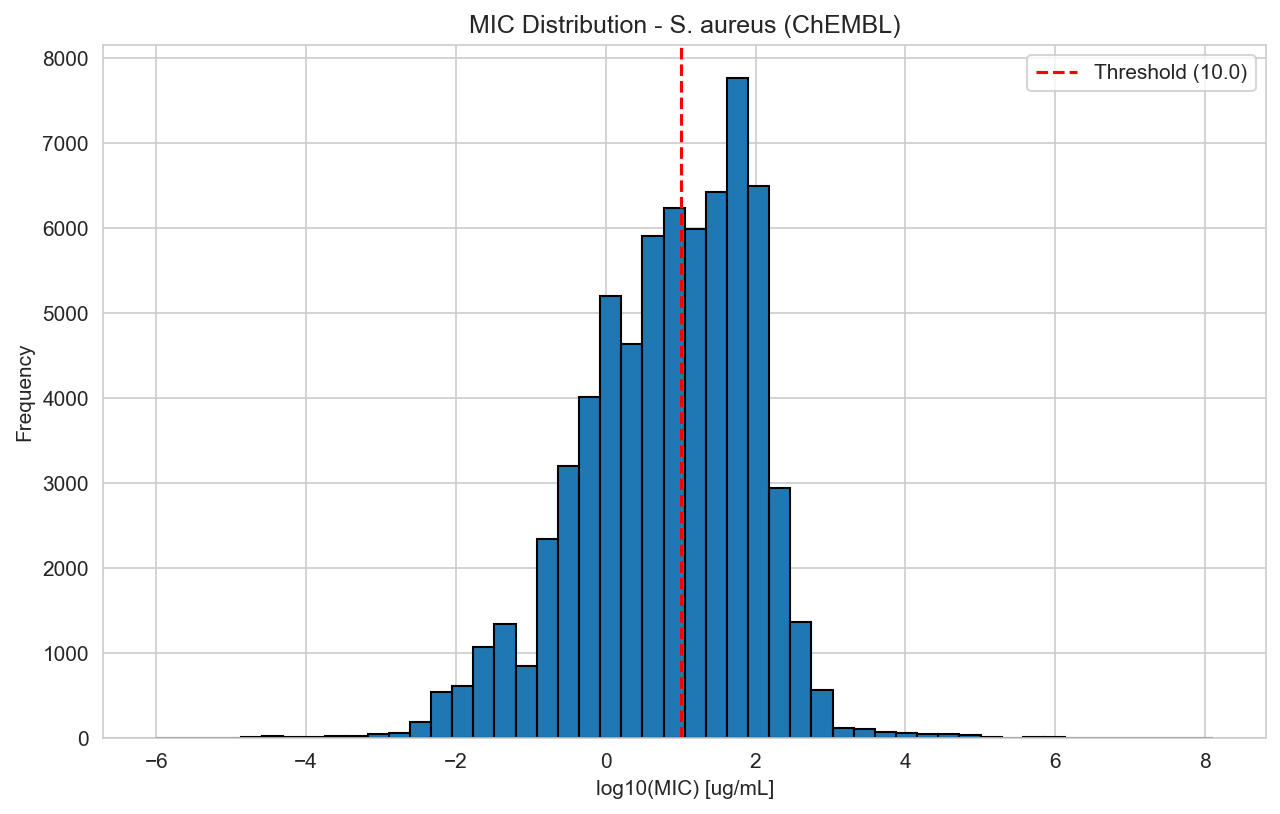

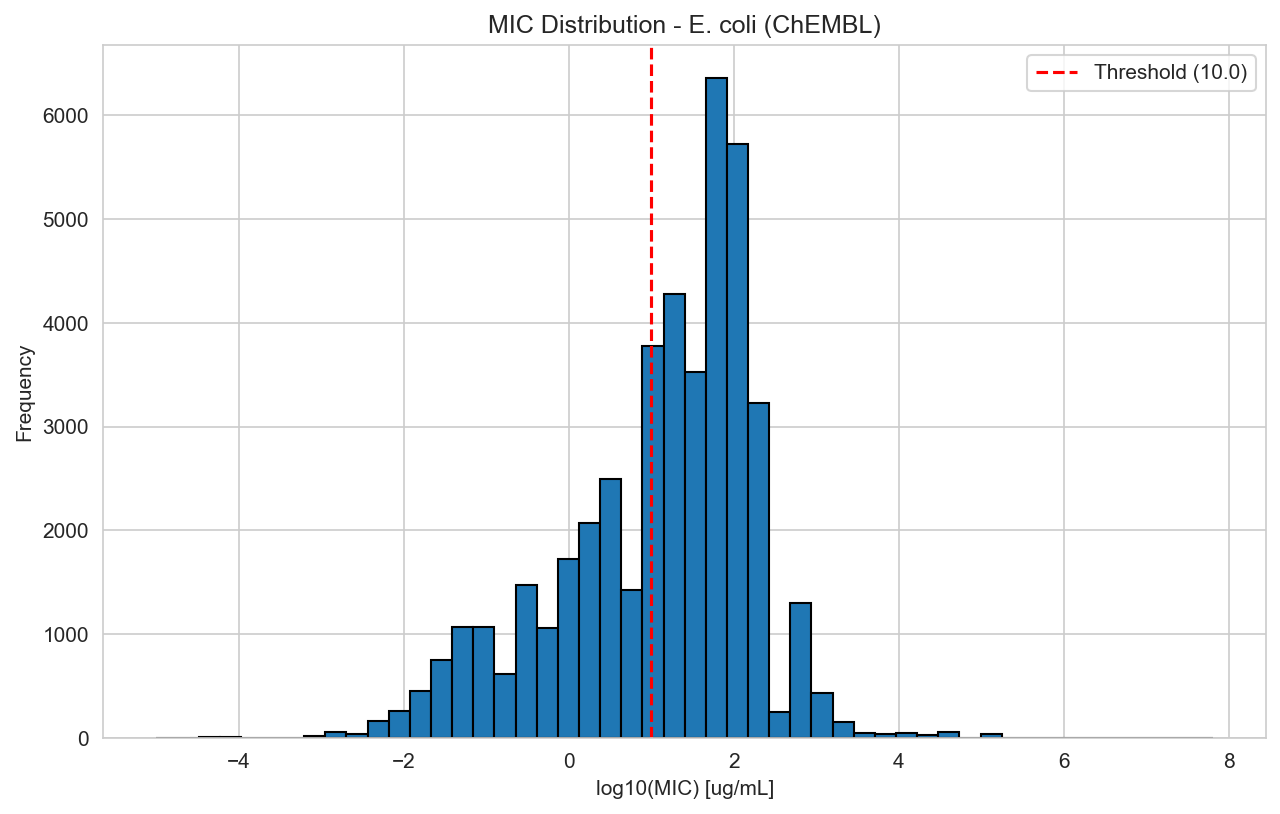

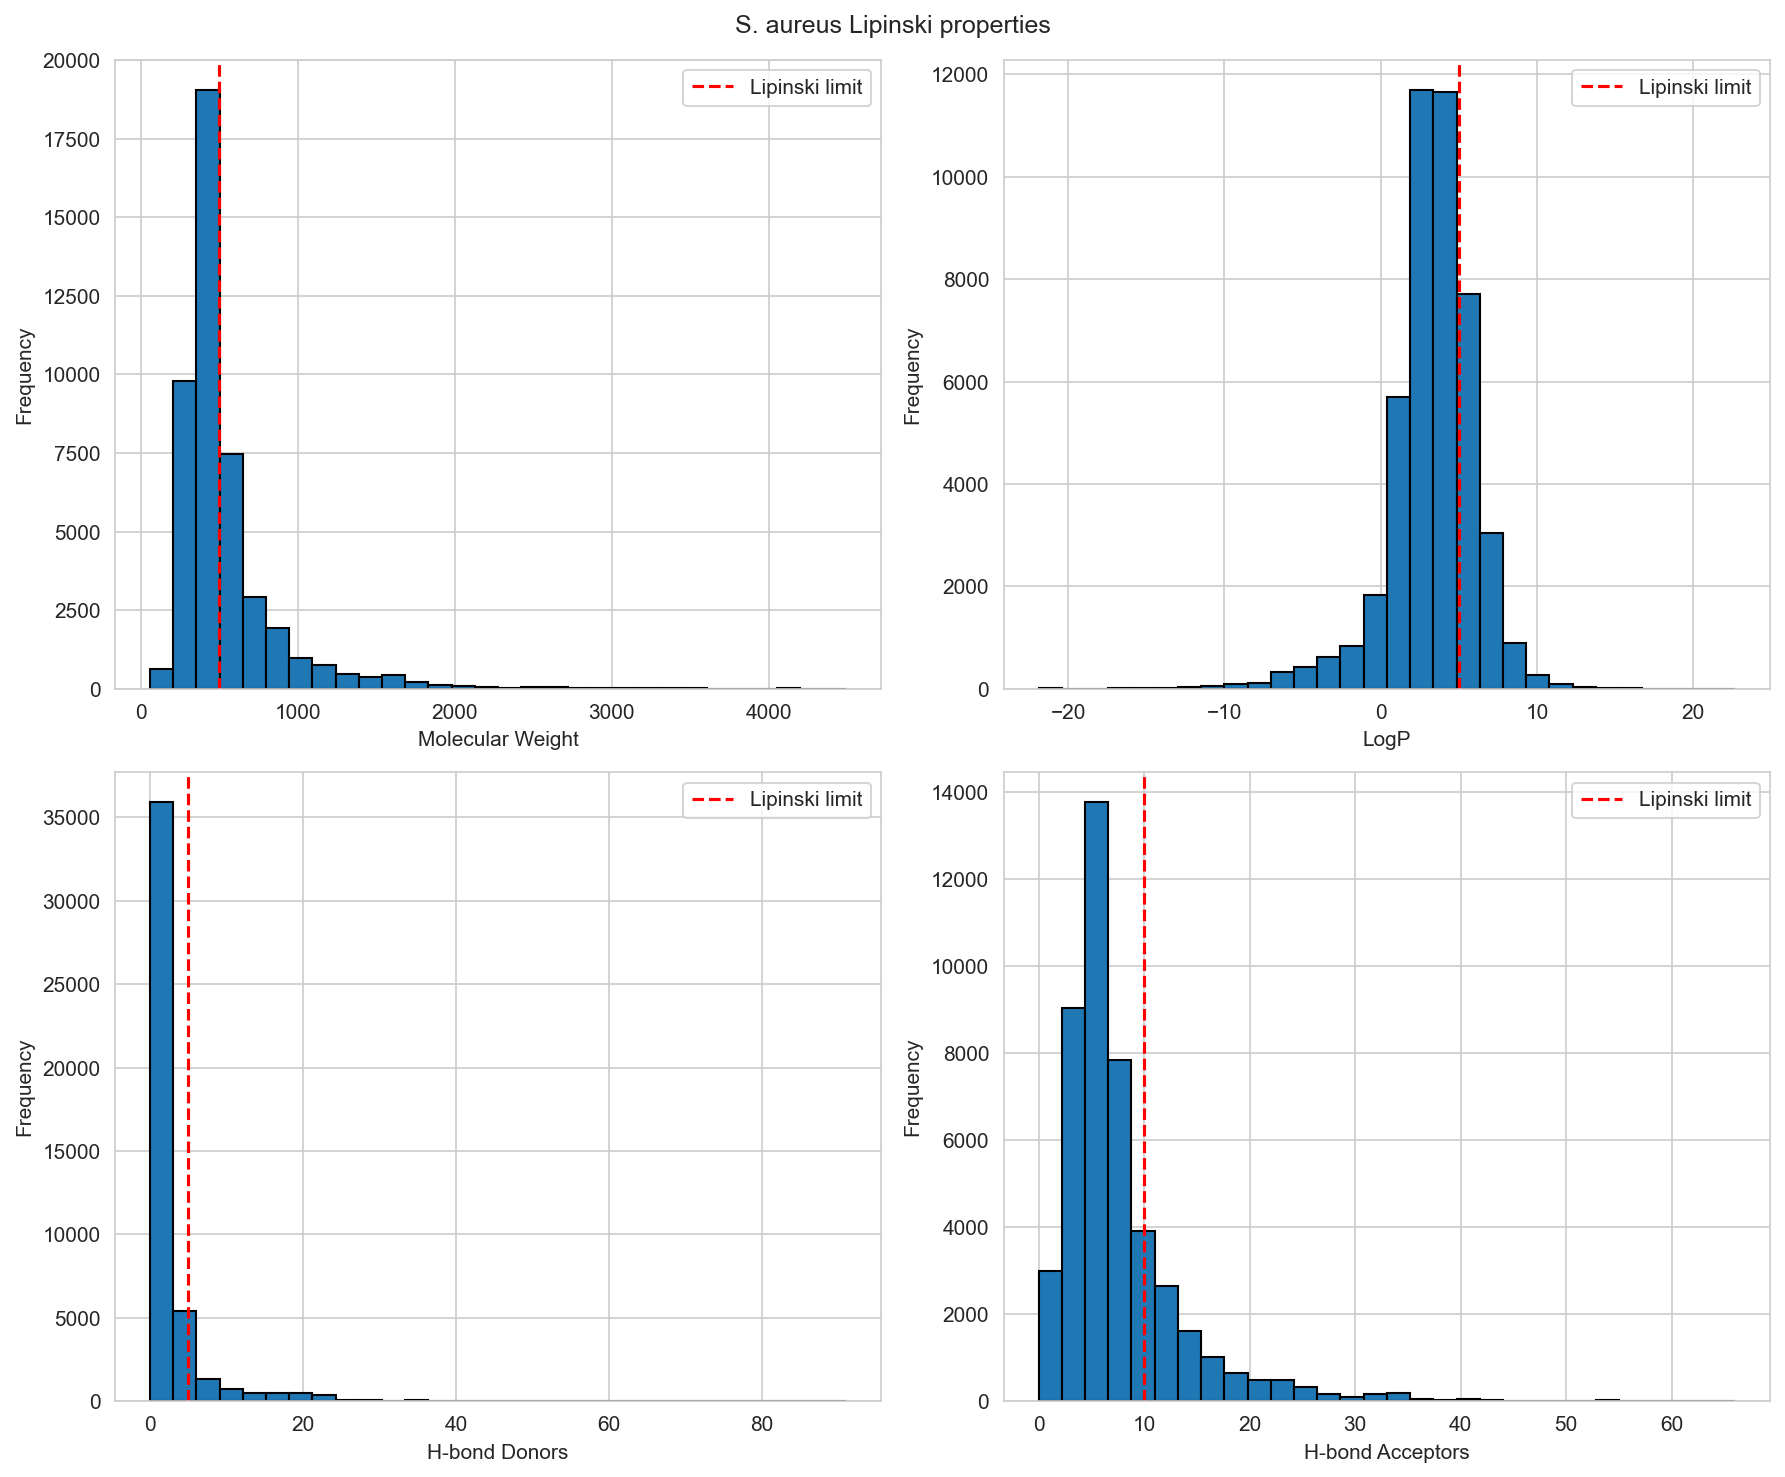

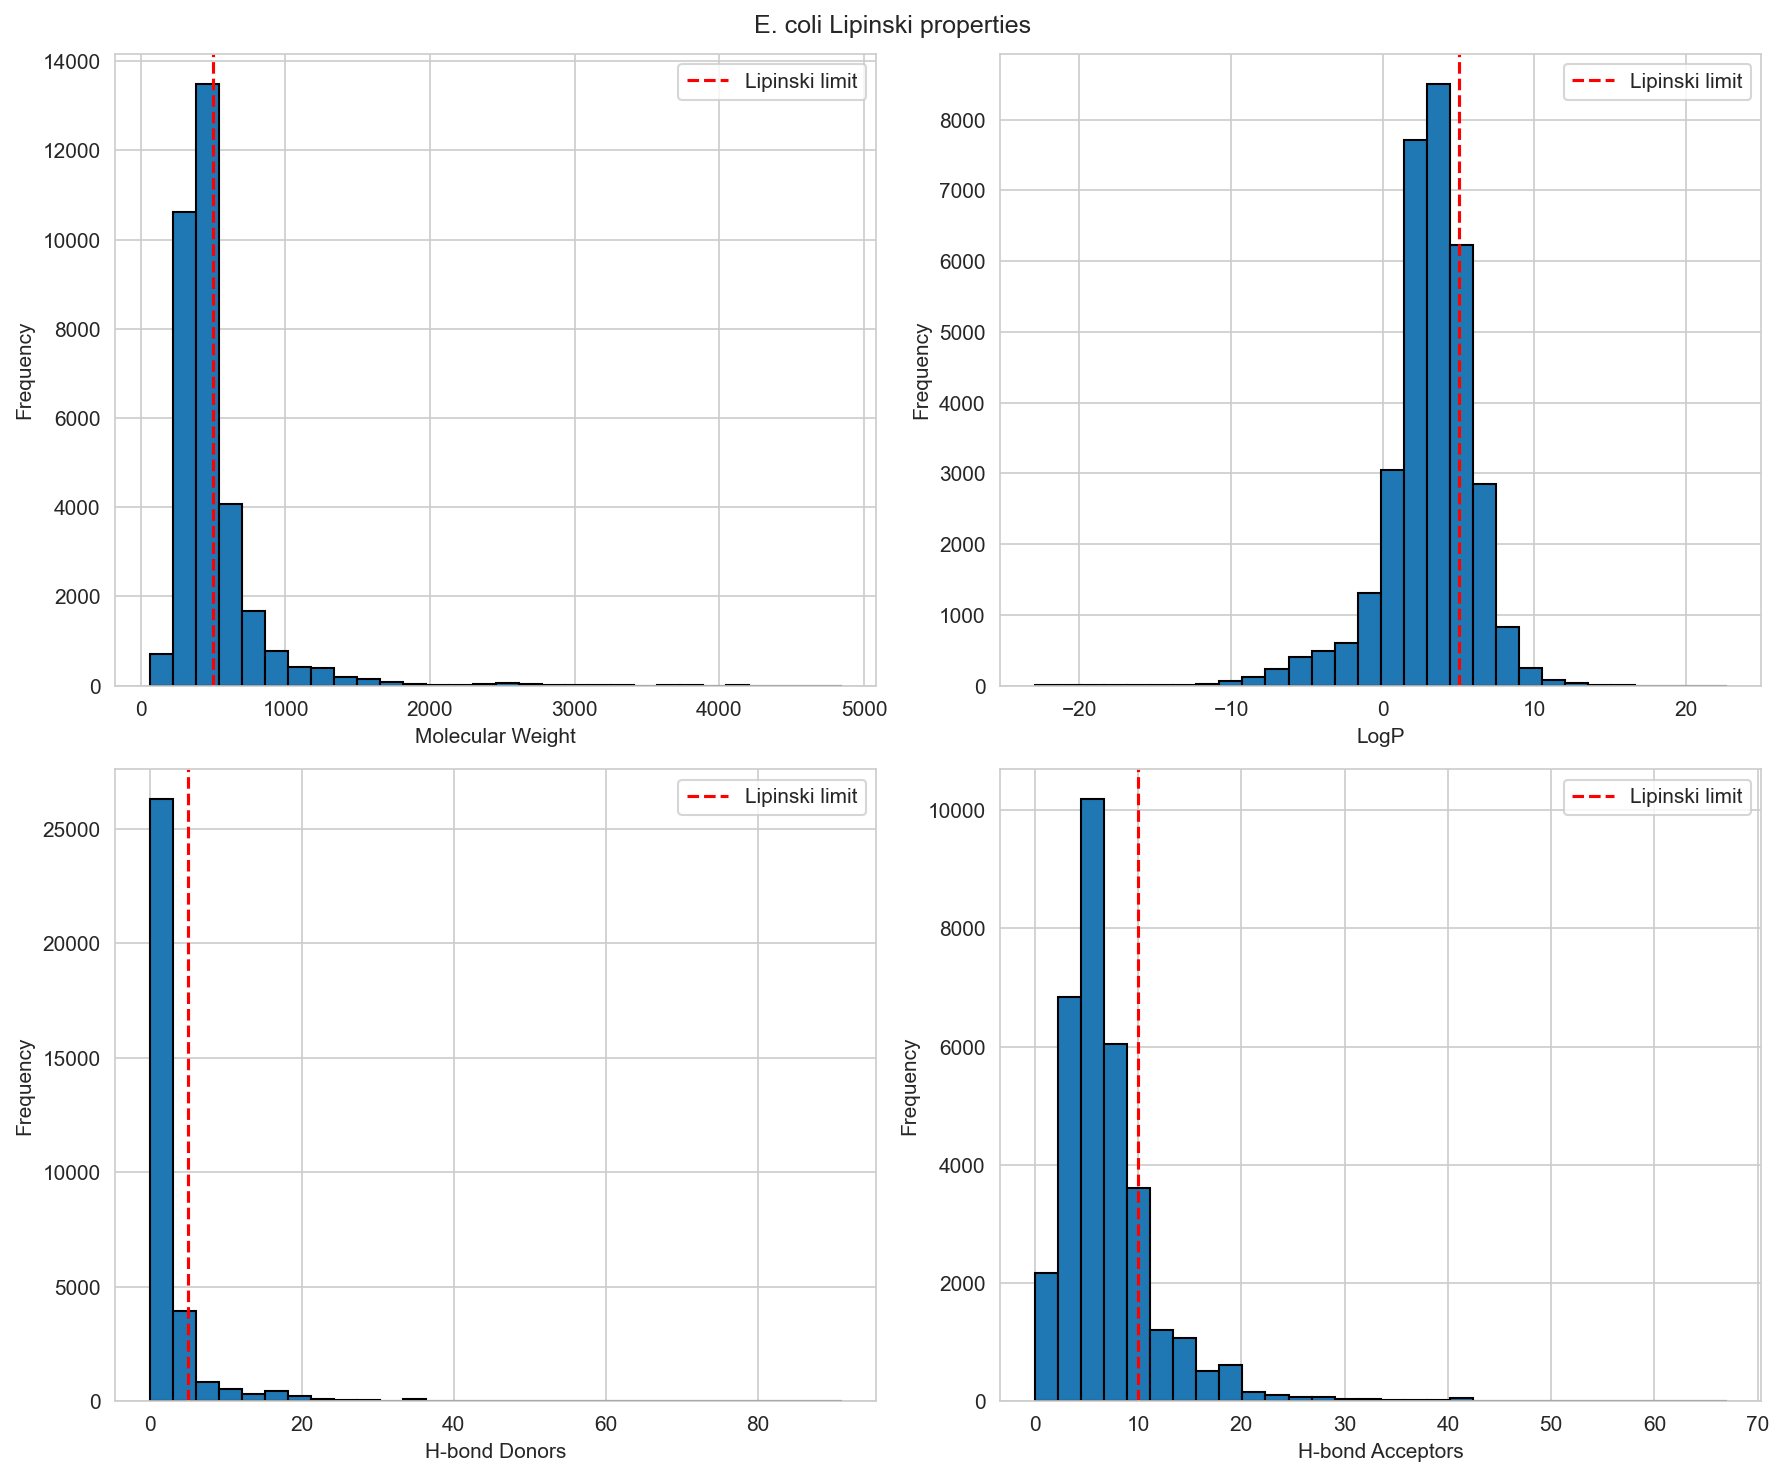

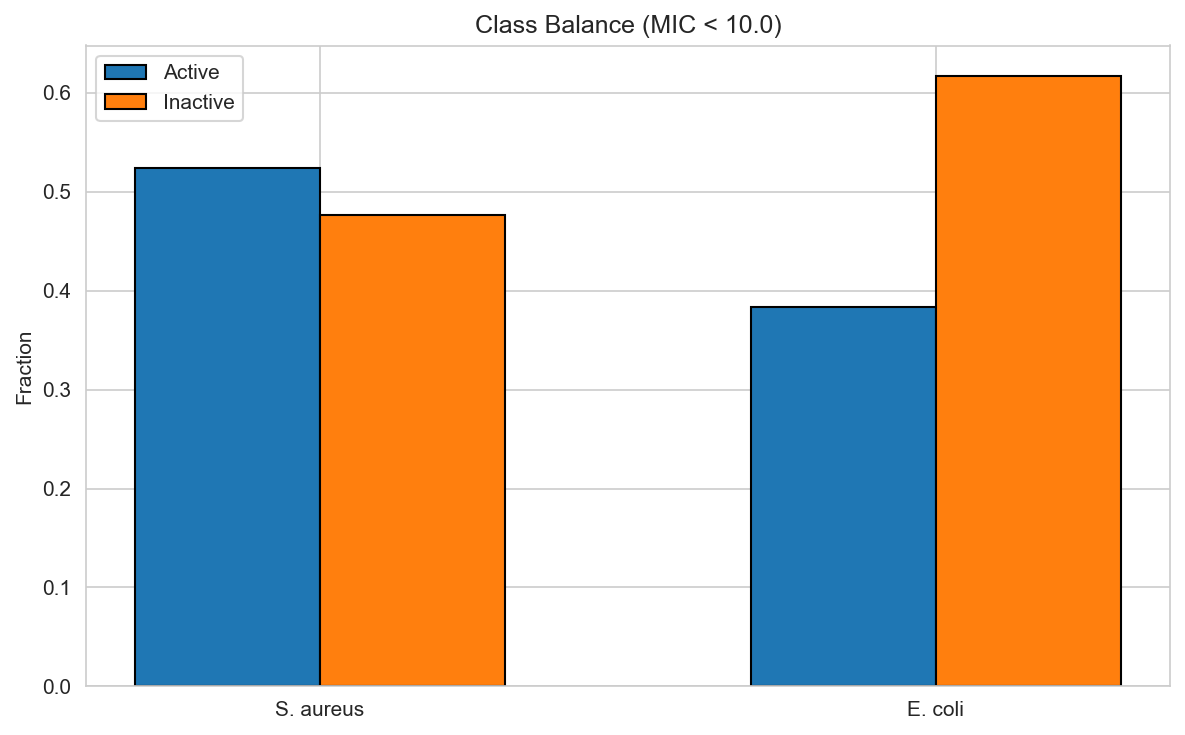

In [9]:
mic_histogram(df_sa, "S. aureus (ChEMBL)", PLOTS / "saureus_mic_dist.png")
mic_histogram(df_ec, "E. coli (ChEMBL)", PLOTS / "ecoli_mic_dist.png")

sa_unique = df_sa["canonical_smiles"].drop_duplicates()
ec_unique = df_ec["canonical_smiles"].drop_duplicates()

sa_props = descriptor_table(sa_unique)
ec_props = descriptor_table(ec_unique)

lipinski_panel(sa_props, PLOTS / "saureus_lipinski.png",
               title="S. aureus Lipinski properties")
lipinski_panel(ec_props, PLOTS / "ecoli_lipinski.png",
               title="E. coli Lipinski properties")

balance_bars(
    [active_frac(df_sa["mic_value"]), active_frac(df_ec["mic_value"])],
    ["S. aureus", "E. coli"],
    PLOTS / "class_balance.png")


## Molecular graph size

  S. aureus heavy atoms: median 31  5th-95th 18-83  99th 133
  E. coli heavy atoms: median 30  5th-95th 18-67  99th 116

  RL max_atoms=50 covers: S. aureus 84.5%, E. coli 89.2% of training molecules


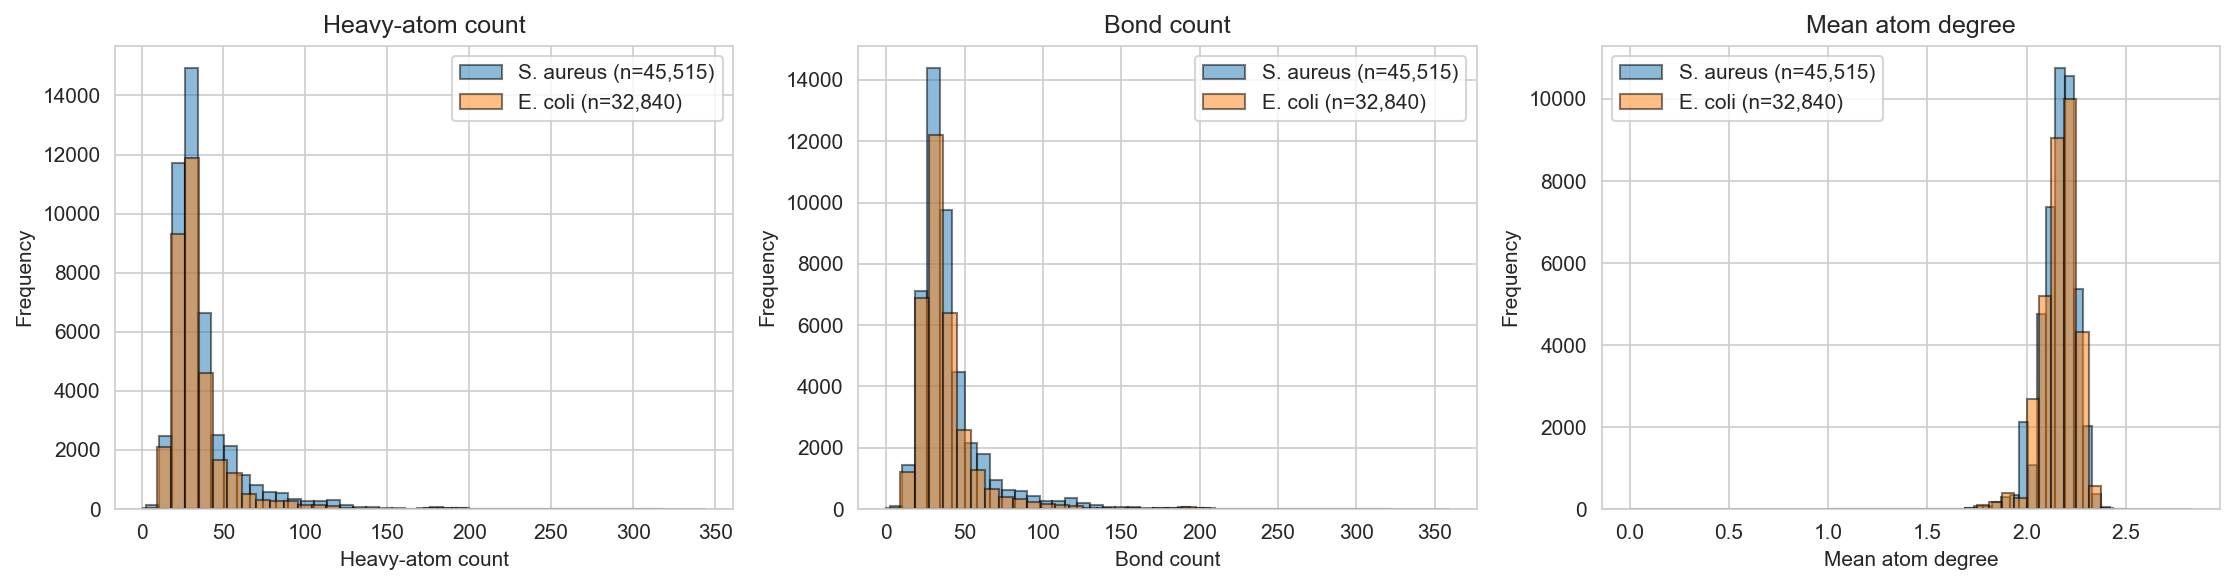

In [10]:
def graph_sizes(smiles_iterable):
    """Per-molecule heavy-atom count, bond count, mean degree."""
    nodes, edges, degree = [], [], []
    for s in smiles_iterable:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            continue
        n = mol.GetNumHeavyAtoms()
        e = mol.GetNumBonds()
        nodes.append(n)
        edges.append(e)
        degree.append(2 * e / max(n, 1))
    return (np.array(nodes, dtype=np.int32),
            np.array(edges, dtype=np.int32),
            np.array(degree, dtype=np.float32))


def graph_size_panel(arrays, save_path):
    """Three histograms - node count, edge count, mean degree."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    titles = ["Heavy-atom count", "Bond count", "Mean atom degree"]
    for arr_dict, ax, title in zip(arrays, axes, titles):
        for label, vals in arr_dict.items():
            ax.hist(vals, bins=40, alpha=0.5, edgecolor="black",
                    label=f"{label} (n={len(vals):,})")
        ax.set(xlabel=title, ylabel="Frequency", title=title)
        ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


sa_nodes, sa_edges, sa_deg = graph_sizes(sa_unique)
ec_nodes, ec_edges, ec_deg = graph_sizes(ec_unique)

for label, arr in [("S. aureus heavy atoms", sa_nodes),
                   ("E. coli heavy atoms",   ec_nodes)]:
    q = np.quantile(arr, [0.05, 0.5, 0.95, 0.99])
    print(f"  {label}: median {int(q[1])}  "
          f"5th-95th {int(q[0])}-{int(q[2])}  99th {int(q[3])}")
print(f"\n  RL max_atoms=50 covers: "
      f"S. aureus {(sa_nodes <= 50).mean():.1%}, "
      f"E. coli {(ec_nodes <= 50).mean():.1%} of training molecules")

graph_size_panel(
    [{"S. aureus": sa_nodes, "E. coli": ec_nodes},
     {"S. aureus": sa_edges, "E. coli": ec_edges},
     {"S. aureus": sa_deg,   "E. coli": ec_deg}],
    PLOTS / "graph_sizes.png")


## RL action-space coverage

In [11]:
RL_ATOMS = {"C", "N", "O", "S", "F", "Cl"}


def atom_vocabulary_split(smiles_iterable):
    """In-vocab vs out-of-vocab counts for the RL action set."""
    in_vocab, out_vocab, parse_fail, oos_atoms = 0, 0, 0, []
    for s in smiles_iterable:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            parse_fail += 1
            continue
        symbols = {a.GetSymbol() for a in mol.GetAtoms()}
        oos = symbols - RL_ATOMS
        if oos:
            out_vocab += 1
            oos_atoms.extend(oos)
        else:
            in_vocab += 1
    return in_vocab, out_vocab, parse_fail, pd.Series(oos_atoms).value_counts()


for label, smiles in [("S. aureus", sa_unique), ("E. coli", ec_unique)]:
    iv, ov, pf, top = atom_vocabulary_split(smiles)
    total = iv + ov + pf
    print(f"\n{label}: n_unique={total:,}")
    print(f"  in RL vocab (C,N,O,S,F,Cl only): "
          f"{iv:>6,}  ({iv/total:.1%})")
    print(f"  contains out-of-vocab atom:      "
          f"{ov:>6,}  ({ov/total:.1%})")
    if pf:
        print(f"  parse failures:                  {pf:>6,}")
    if not top.empty:
        print(f"  most common out-of-vocab atoms (top 8):")
        for atom, n in top.head(8).items():
            print(f"    {atom:<4} {n:>6,}")



S. aureus: n_unique=45,515
  in RL vocab (C,N,O,S,F,Cl only): 40,633  (89.3%)
  contains out-of-vocab atom:       4,882  (10.7%)
  most common out-of-vocab atoms (top 8):
    Br    3,094
    I       549
    P       500
    Na      390
    B       300
    K        63
    Se       61
    Si       46

E. coli: n_unique=32,840
  in RL vocab (C,N,O,S,F,Cl only): 29,169  (88.8%)
  contains out-of-vocab atom:       3,671  (11.2%)
  most common out-of-vocab atoms (top 8):
    Br    2,179
    P       425
    Na      409
    I       341
    B       233
    Se       85
    K        65
    Si       33


## Atom-fraction distribution of the active subset

In [12]:
def active_atom_fractions(df, smiles_col="canonical_smiles",
                          mic_col="mic_value", threshold=MIC_THRESHOLD):
    """Mean atom-symbol fraction across compounds with median MIC below threshold."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    medians = clean.groupby(smiles_col)["log_mic"].median()
    actives = medians[medians < np.log10(threshold)].index
    counts = pd.Series(0.0, index=list(RL_ATOMS) + ["other"])
    n_mol, total_atoms = 0, 0
    for smi in actives:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        n_mol += 1
        for atom in mol.GetAtoms():
            sym = atom.GetSymbol()
            counts[sym if sym in RL_ATOMS else "other"] += 1
            total_atoms += 1
    if total_atoms == 0:
        return None
    return {"n_actives": n_mol,
            "fractions": (counts / total_atoms).sort_values(ascending=False)}


for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    r = active_atom_fractions(df)
    if r is None:
        print(f"{label}: no actives")
        continue
    print(f"\n{label}: n_actives={r['n_actives']:,}")
    for sym, frac in r["fractions"].items():
        print(f"  {sym:<5} {frac:>6.1%}")


S. aureus: n_actives=20,673
  C      70.6%
  O      14.5%
  N      11.1%
  F       1.5%
  S       1.2%
  Cl      0.8%
  other   0.3%

E. coli: n_actives=10,187
  C      68.7%
  N      13.5%
  O      13.3%
  F       1.9%
  S       1.4%
  Cl      0.8%
  other   0.4%


## Scaffold inventory and active-compound concentration

In [13]:
sa_scaf = scaffolds(sa_unique)
ec_scaf = scaffolds(ec_unique)

for name, s in [("S. aureus", sa_scaf), ("E. coli", ec_scaf)]:
    valid = s.dropna()
    n, u = len(valid), valid.nunique()
    print(f"  {name}: {n:,} molecules, {u:,} scaffolds, "
          f"ratio {u / max(n, 1):.3f}")


def active_scaffold_concentration(df, smiles_col="canonical_smiles",
                                  mic_col="mic_value",
                                  threshold=MIC_THRESHOLD):
    """Cumulative coverage of active compounds by their top scaffolds."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    agg = clean.groupby(smiles_col)["log_mic"].median()
    actives = agg[agg < np.log10(threshold)].index.tolist()
    if not actives:
        return None
    sc = pd.Series(pool_map(bemis_murcko_scaffold, actives, N_WORKERS))
    sc = sc.dropna()
    counts = sc.value_counts()
    n_active = len(sc)
    return {
        "n_actives": n_active,
        "n_scaffolds": len(counts),
        "top10_frac":  float(counts.head(10).sum()  / n_active),
        "top50_frac":  float(counts.head(50).sum()  / n_active),
        "top100_frac": float(counts.head(100).sum() / n_active),
        "top1_count":  int(counts.iloc[0]) if not counts.empty else 0,
        "top1_scaffold": counts.index[0] if not counts.empty else "",
    }


for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    result = active_scaffold_concentration(df)
    if result is None:
        print(f"  {label}: no actives")
        continue
    print(f"\n{label}: {result['n_actives']:,} active compounds, "
          f"{result['n_scaffolds']:,} unique scaffolds among actives")
    print(f"  top  10 scaffolds cover: {result['top10_frac']:.1%} of actives")
    print(f"  top  50 scaffolds cover: {result['top50_frac']:.1%} of actives")
    print(f"  top 100 scaffolds cover: {result['top100_frac']:.1%} of actives")
    print(f"  most populous scaffold ({result['top1_count']:,} actives):")
    print(f"    {result['top1_scaffold']}")


  S. aureus: 45,515 molecules, 15,074 scaffolds, ratio 0.331
  E. coli: 32,840 molecules, 10,360 scaffolds, ratio 0.315

S. aureus: 20,673 active compounds, 7,891 unique scaffolds among actives
  top  10 scaffolds cover: 6.4% of actives
  top  50 scaffolds cover: 14.1% of actives
  top 100 scaffolds cover: 20.1% of actives
  most populous scaffold (263 actives):
    

E. coli: 10,187 active compounds, 3,833 unique scaffolds among actives
  top  10 scaffolds cover: 10.0% of actives
  top  50 scaffolds cover: 21.3% of actives
  top 100 scaffolds cover: 28.3% of actives
  most populous scaffold (171 actives):
    O=c1ccn(C2CC2)c2cc(N3CCCC3)ccc12


## Reference set coverage: DrugBank and CARD vs training

  Train: (78355, 2048)  DrugBank: (458, 2048)  CARD: (457, 2048)

DrugBank antibiotics vs ChEMBL training set:
  DrugBank: n=458  >=0.4: 87.8%  >=0.6: 74.0%  ~identical: 51.1%  median: 1.000

CARD substrates vs ChEMBL training set:
  CARD: n=457  >=0.4: 87.7%  >=0.6: 74.2%  ~identical: 51.2%  median: 1.000


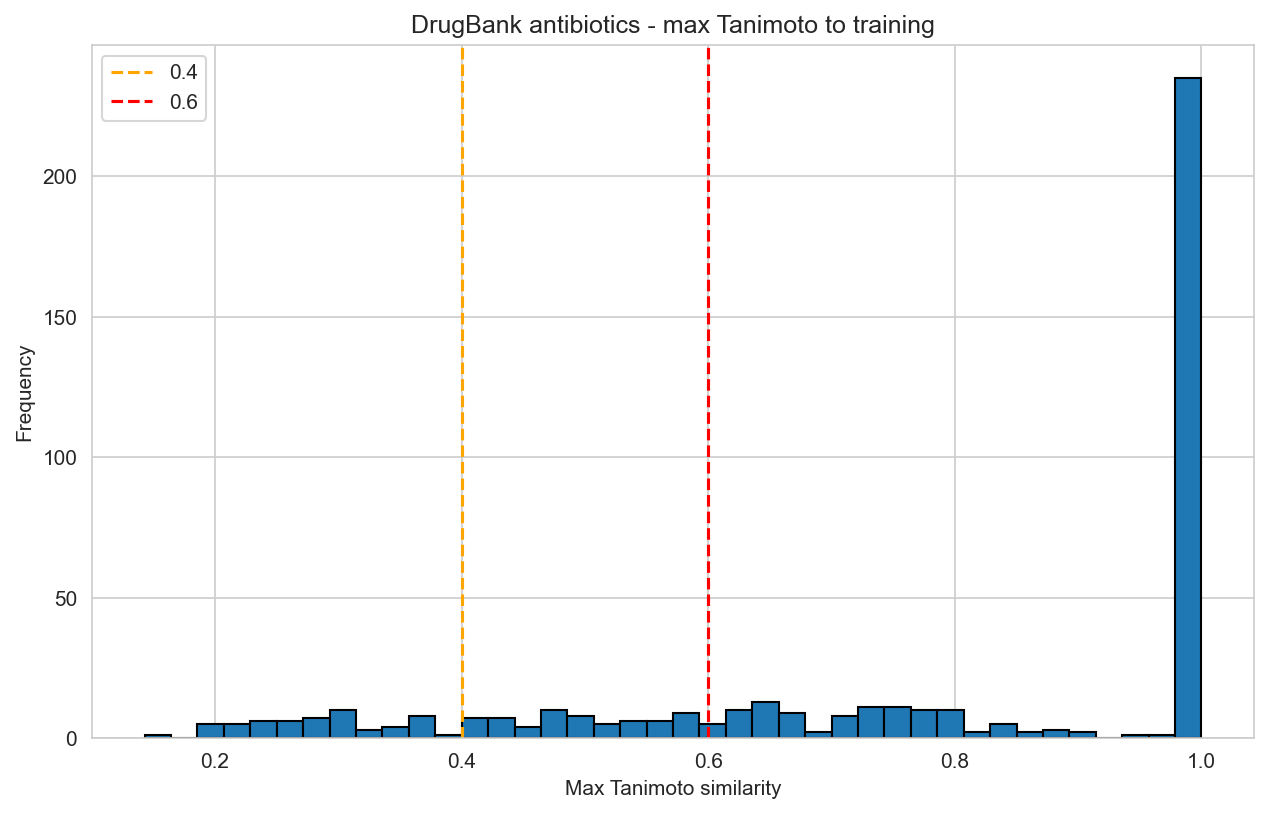

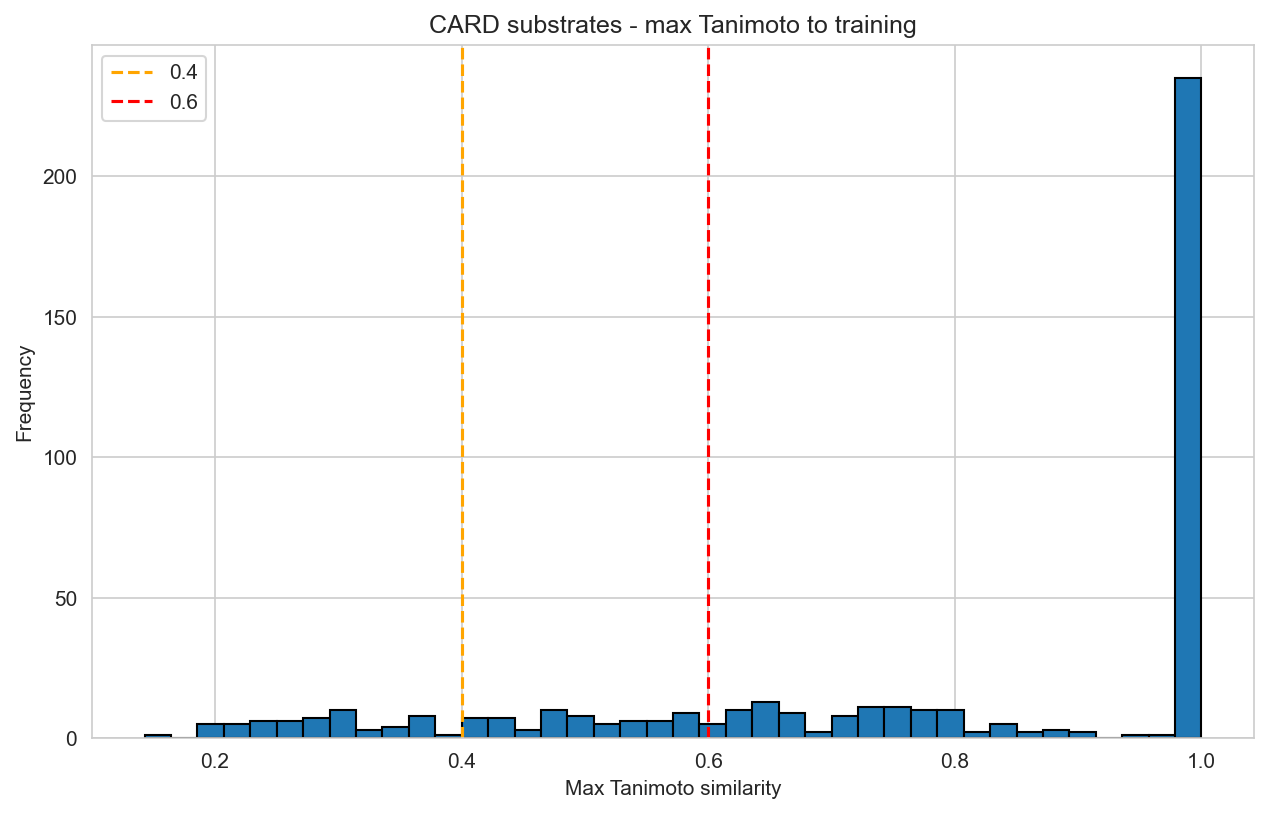

In [14]:
sa_fps = fingerprint_matrix(sa_unique)
ec_fps = fingerprint_matrix(ec_unique)
ab_fps = fingerprint_matrix(df_ab["smiles"].dropna().unique())
card_fps = fingerprint_matrix(substrates["smiles"].dropna().unique())

train_fps = np.vstack([sa_fps, ec_fps])
print(f"  Train: {train_fps.shape}  DrugBank: {ab_fps.shape}  "
      f"CARD: {card_fps.shape}")

print("\nDrugBank antibiotics vs ChEMBL training set:")
ab_sim = coverage_stats("DrugBank", ab_fps, train_fps)

print("\nCARD substrates vs ChEMBL training set:")
card_sim = coverage_stats("CARD", card_fps, train_fps)

similarity_density(ab_sim, PLOTS / "drugbank_vs_train_similarity.png",
                   title="DrugBank antibiotics - max Tanimoto to training")
similarity_density(card_sim, PLOTS / "card_vs_train_similarity.png",
                   title="CARD substrates - max Tanimoto to training")


## Threshold borderline and log-MIC replicate variance

In [15]:
for org, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    f2 = borderline_fraction(df["mic_value"], factor=2.0)
    f3 = borderline_fraction(df["mic_value"], factor=3.0)
    tiers = activity_tiers(df["mic_value"]).value_counts(normalize=True)
    print(f"{org}:")
    print(f"  MIC within 2x of threshold: {f2:.1%}")
    print(f"  MIC within 3x of threshold: {f3:.1%}")
    print(f"  Activity tiers: "
          + "  ".join(f"{k}: {v:.1%}" for k, v in tiers.items()))


print("\nLog-MIC replicate variance:")
for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    cv = log_replicate_variance(df, "canonical_smiles", "mic_value")
    if cv.empty:
        print(f"  {label}: no replicate measurements")
        continue
    print(f"  {label}: median CV (log) {cv['cv'].median():.3f}  "
          f"std (log) {cv['std'].median():.3f}  "
          f"std > 0.5: {(cv['std'] > 0.5).mean():.1%}")


S. aureus:
  MIC within 2x of threshold: 18.4%
  MIC within 3x of threshold: 27.5%
  Activity tiers: Active: 31.2%  Moderate: 30.5%  Highly Active: 21.2%  Inactive: 17.1%
E. coli:
  MIC within 2x of threshold: 17.8%
  MIC within 3x of threshold: 25.5%
  Activity tiers: Moderate: 36.1%  Inactive: 25.6%  Active: 21.2%  Highly Active: 17.1%

Log-MIC replicate variance:
  S. aureus: median CV (log) 0.593  std (log) 0.426  std > 0.5: 39.2%
  E. coli: median CV (log) 0.624  std (log) 0.624  std > 0.5: 53.7%


## Replicate noise vs threshold distance


S. aureus:
  <0.3 (~2x)      n=2851  median std=0.426
  0.3-0.6         n=2765  median std=0.426
  0.6-1.0         n=3753  median std=0.301
  1.0-2.0         n=3281  median std=0.426
  >2.0            n= 953  median std=0.460


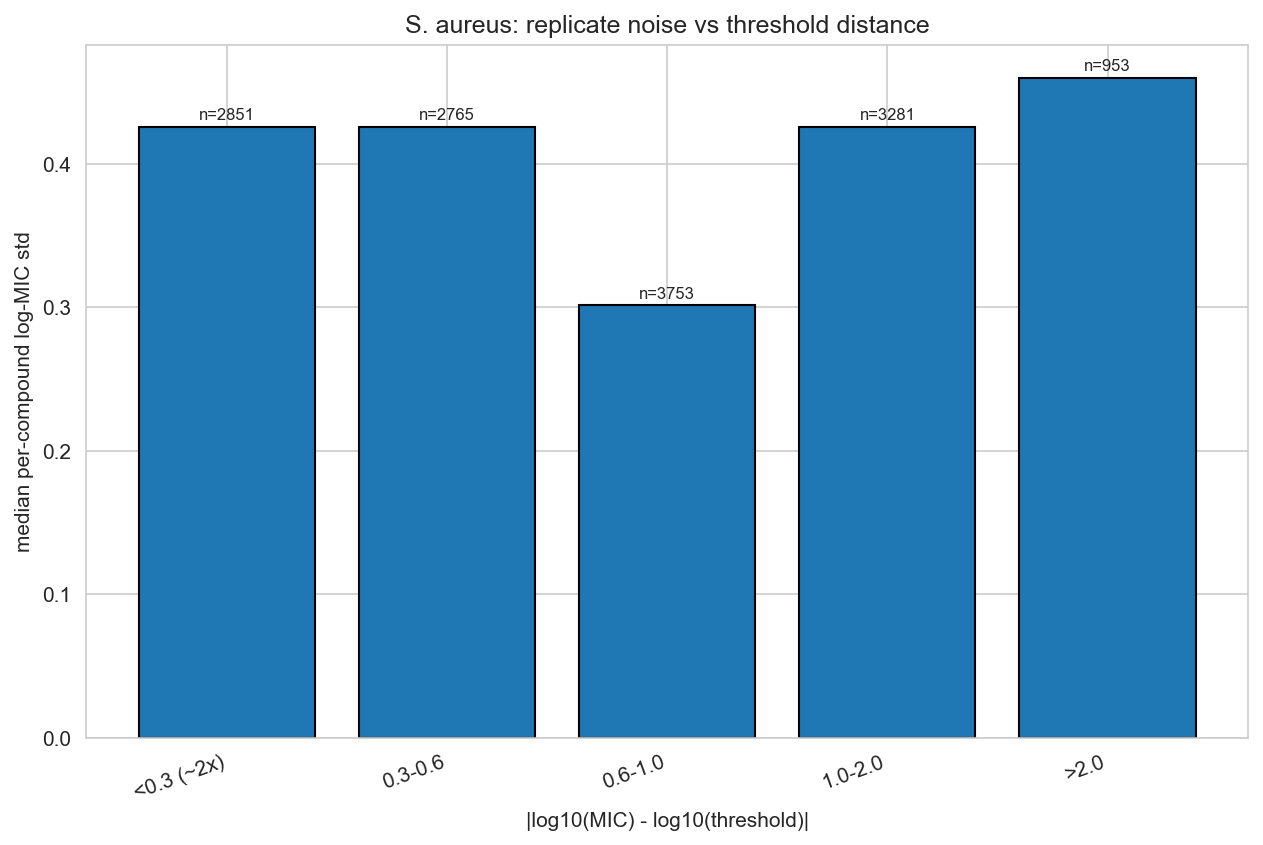


E. coli:
  <0.3 (~2x)      n=1177  median std=0.720
  0.3-0.6         n=1132  median std=0.639
  0.6-1.0         n=1360  median std=0.426
  1.0-2.0         n=1198  median std=0.438
  >2.0            n= 437  median std=0.438


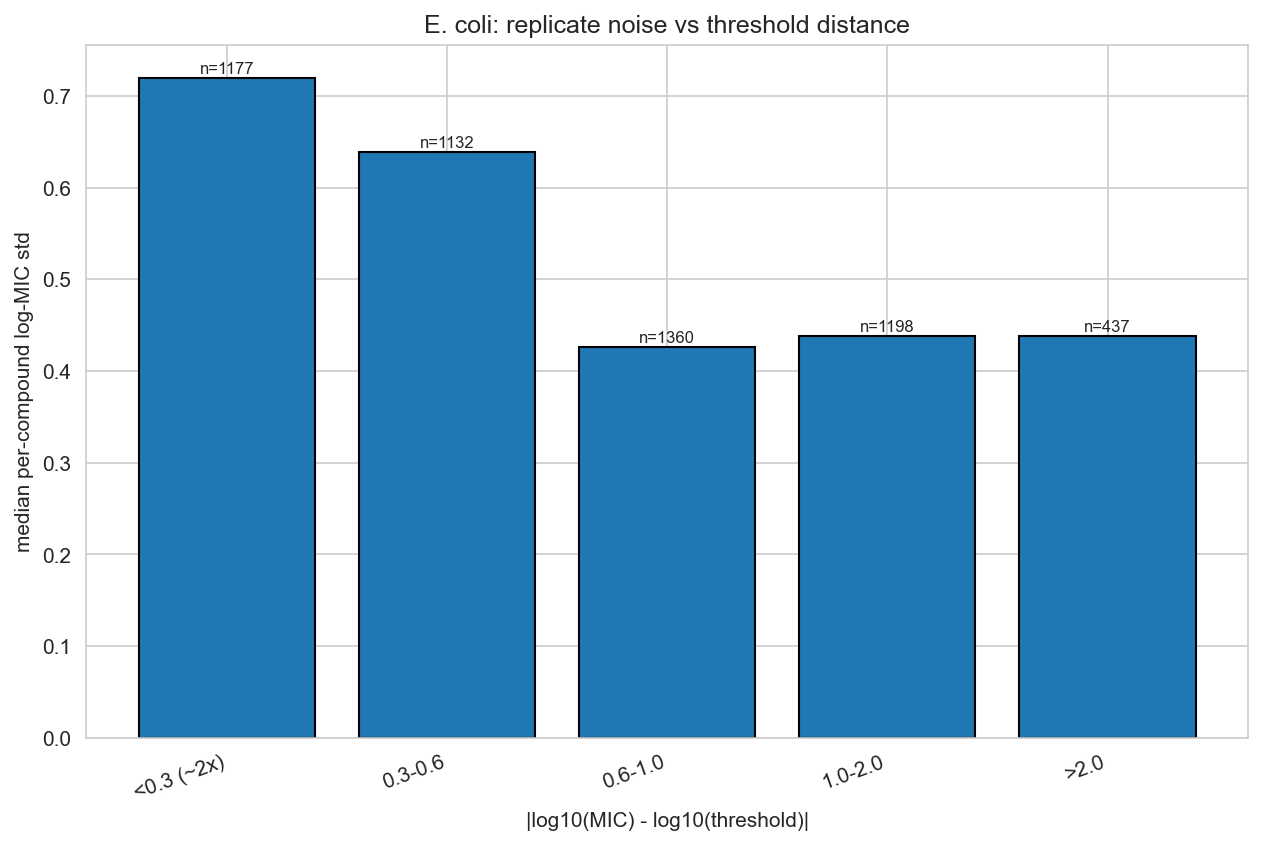

In [16]:
for label, df, fname in [
    ("S. aureus", df_sa, "saureus_noise_vs_threshold.png"),
    ("E. coli",   df_ec, "ecoli_noise_vs_threshold.png"),
]:
    stats = noise_by_threshold_distance(df, "canonical_smiles", "mic_value")
    if stats.empty:
        print(f"{label}: no replicate measurements")
        continue
    by_bin = (stats.groupby("bin", observed=True)["std"]
              .agg(["median", "count"]))
    print(f"\n{label}:")
    for bin_label, row in by_bin.iterrows():
        print(f"  {str(bin_label):<14}  n={int(row['count']):>4}  "
              f"median std={row['median']:.3f}")
    noise_distance_chart(stats, label, PLOTS / fname)


## Aggregation impact and label flips

In [17]:
for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    raw_active = active_frac(df["mic_value"])
    agg_active, n_agg = aggregated_actives(df)
    n_flips, n_multi = label_flips(df)
    flip_rate = n_flips / max(n_multi, 1)
    print(f"{label}:")
    print(f"  raw active rate (replicates):    {raw_active:.1%}  "
          f"(n={len(df):,})")
    print(f"  aggregated active rate (median): {agg_active:.1%}  "
          f"(n={n_agg:,})")
    print(f"  label flips across replicates:   "
          f"{n_flips:,}/{n_multi:,} compounds ({flip_rate:.1%})")


S. aureus:
  raw active rate (replicates):    52.4%  (n=68,511)
  aggregated active rate (median): 45.5%  (n=45,485)
  label flips across replicates:   4,504/13,633 compounds (33.0%)
E. coli:
  raw active rate (replicates):    38.3%  (n=44,131)
  aggregated active rate (median): 31.0%  (n=32,829)
  label flips across replicates:   2,141/5,311 compounds (40.3%)


## Label-flip rate by distance from threshold

In [18]:
for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    table = label_flip_by_distance(df)
    if table.empty:
        print(f"{label}: no replicate measurements")
        continue
    table["flip_rate"] = (table["n_flips"]
                          / table["n_compounds"].clip(lower=1))
    print(f"\n{label}:")
    print(f"  {'distance':<12} {'n_compounds':>12} {'n_flips':>9} "
          f"{'flip_rate':>10}")
    for bin_label, row in table.iterrows():
        print(f"  {str(bin_label):<12} {int(row['n_compounds']):>12} "
              f"{int(row['n_flips']):>9} {row['flip_rate']:>10.1%}")
    near = table.iloc[0]
    near_rate = near["n_flips"] / max(near["n_compounds"], 1)
    print(f"  Within 2x of threshold: {near_rate:.1%} flip rate "
          f"(n={int(near['n_compounds']):,})  -- noise ceiling for "
          f"binary classification")



S. aureus:
  distance      n_compounds   n_flips  flip_rate
  <0.3 (~2x)           2851      2262      79.3%
  0.3-0.6              2765      1055      38.2%
  0.6-1.0              3753       690      18.4%
  1.0-2.0              3281       422      12.9%
  >2.0                  953        45       4.7%
  Within 2x of threshold: 79.3% flip rate (n=2,851)  -- noise ceiling for binary classification

E. coli:
  distance      n_compounds   n_flips  flip_rate
  <0.3 (~2x)           1177      1052      89.4%
  0.3-0.6              1132       626      55.3%
  0.6-1.0              1360       289      21.2%
  1.0-2.0              1198       148      12.4%
  >2.0                  437        19       4.3%
  Within 2x of threshold: 89.4% flip rate (n=1,177)  -- noise ceiling for binary classification


## Cross-organism overlap and log-MIC correlation

Compounds in S. aureus only: 17,231
Compounds in E. coli only:   4,556
Shared compounds:            28,284

Log-MIC agreement on shared compounds:
  Pearson r:  0.751
  Spearman r: 0.731
  Same binary label at threshold: 79.2%


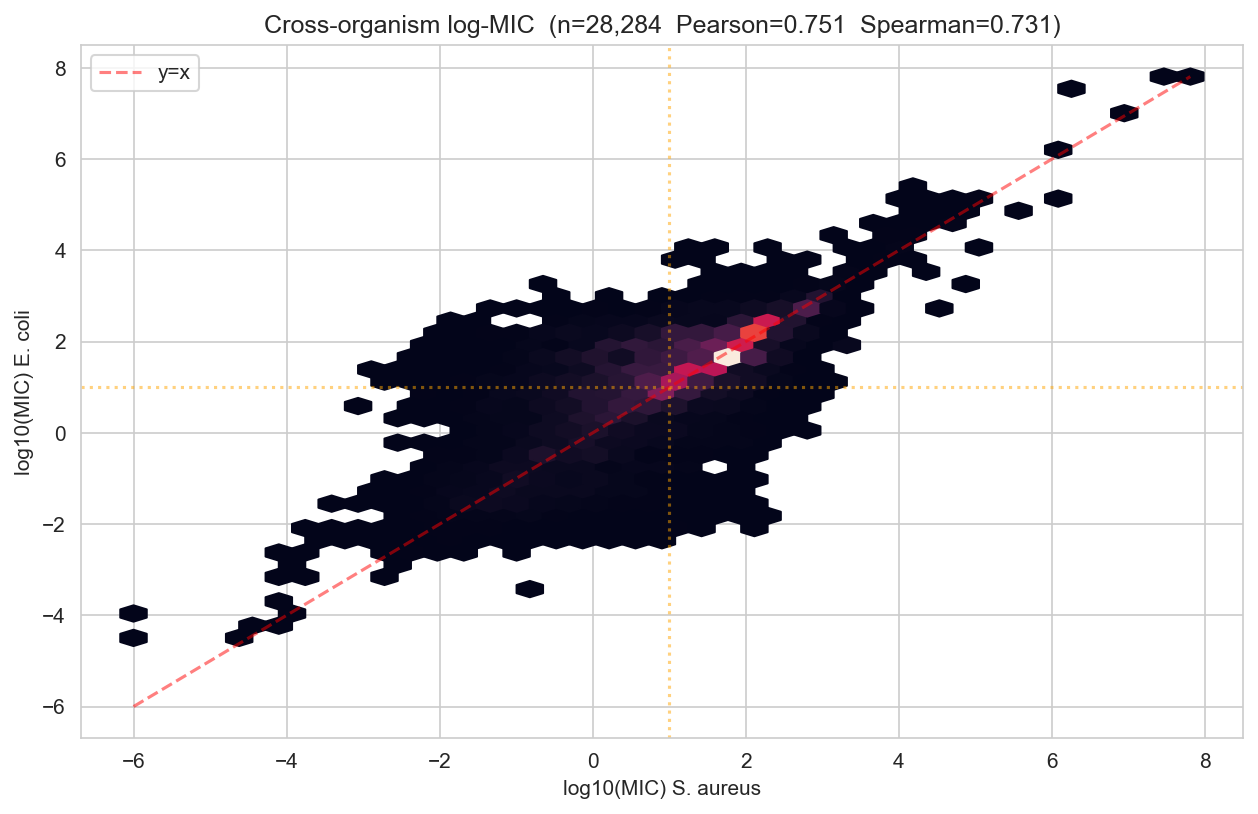

In [19]:
def cross_organism_overlap(df_a, df_b, label_a, label_b):
    """Per-compound median log10(MIC) inner-joined across two organisms."""
    def per_compound(df):
        clean = df.dropna(subset=["canonical_smiles", "mic_value"])
        clean = clean[clean["mic_value"] > 0].copy()
        clean["log_mic"] = np.log10(clean["mic_value"])
        return clean.groupby("canonical_smiles")["log_mic"].median()
    return pd.DataFrame({label_a: per_compound(df_a),
                         label_b: per_compound(df_b)}).dropna()


def overlap_correlation_chart(joined, label_a, label_b, save_path):
    """Hexbin scatter with Pearson and Spearman correlations annotated."""
    if joined.empty:
        print("  No shared compounds between organisms")
        return
    pearson = joined.corr(method="pearson").iloc[0, 1]
    spearman = joined.corr(method="spearman").iloc[0, 1]
    fig, ax = plt.subplots()
    ax.hexbin(joined[label_a], joined[label_b], gridsize=40, mincnt=1)
    lo = float(min(joined[label_a].min(), joined[label_b].min()))
    hi = float(max(joined[label_a].max(), joined[label_b].max()))
    ax.plot([lo, hi], [lo, hi], "r--", alpha=0.5, label="y=x")
    ax.axvline(np.log10(MIC_THRESHOLD), color="orange", ls=":", alpha=0.5)
    ax.axhline(np.log10(MIC_THRESHOLD), color="orange", ls=":", alpha=0.5)
    ax.set(xlabel=f"log10(MIC) {label_a}",
           ylabel=f"log10(MIC) {label_b}",
           title=f"Cross-organism log-MIC  (n={len(joined):,}  "
                 f"Pearson={pearson:.3f}  Spearman={spearman:.3f})")
    ax.legend()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


joined = cross_organism_overlap(df_sa, df_ec, "S. aureus", "E. coli")
sa_only = df_sa["canonical_smiles"].nunique() - len(joined)
ec_only = df_ec["canonical_smiles"].nunique() - len(joined)
print(f"Compounds in S. aureus only: {sa_only:,}")
print(f"Compounds in E. coli only:   {ec_only:,}")
print(f"Shared compounds:            {len(joined):,}")

if not joined.empty:
    print("\nLog-MIC agreement on shared compounds:")
    print(f"  Pearson r:  {joined.corr(method='pearson').iloc[0, 1]:.3f}")
    print(f"  Spearman r: {joined.corr(method='spearman').iloc[0, 1]:.3f}")
    same_label = (
        ((joined["S. aureus"] < np.log10(MIC_THRESHOLD)) ==
         (joined["E. coli"]   < np.log10(MIC_THRESHOLD))).mean())
    print(f"  Same binary label at threshold: {same_label:.1%}")

overlap_correlation_chart(
    joined, "S. aureus", "E. coli",
    PLOTS / "cross_organism_overlap.png")


## Molecular weight: training vs reference, and activity by MW

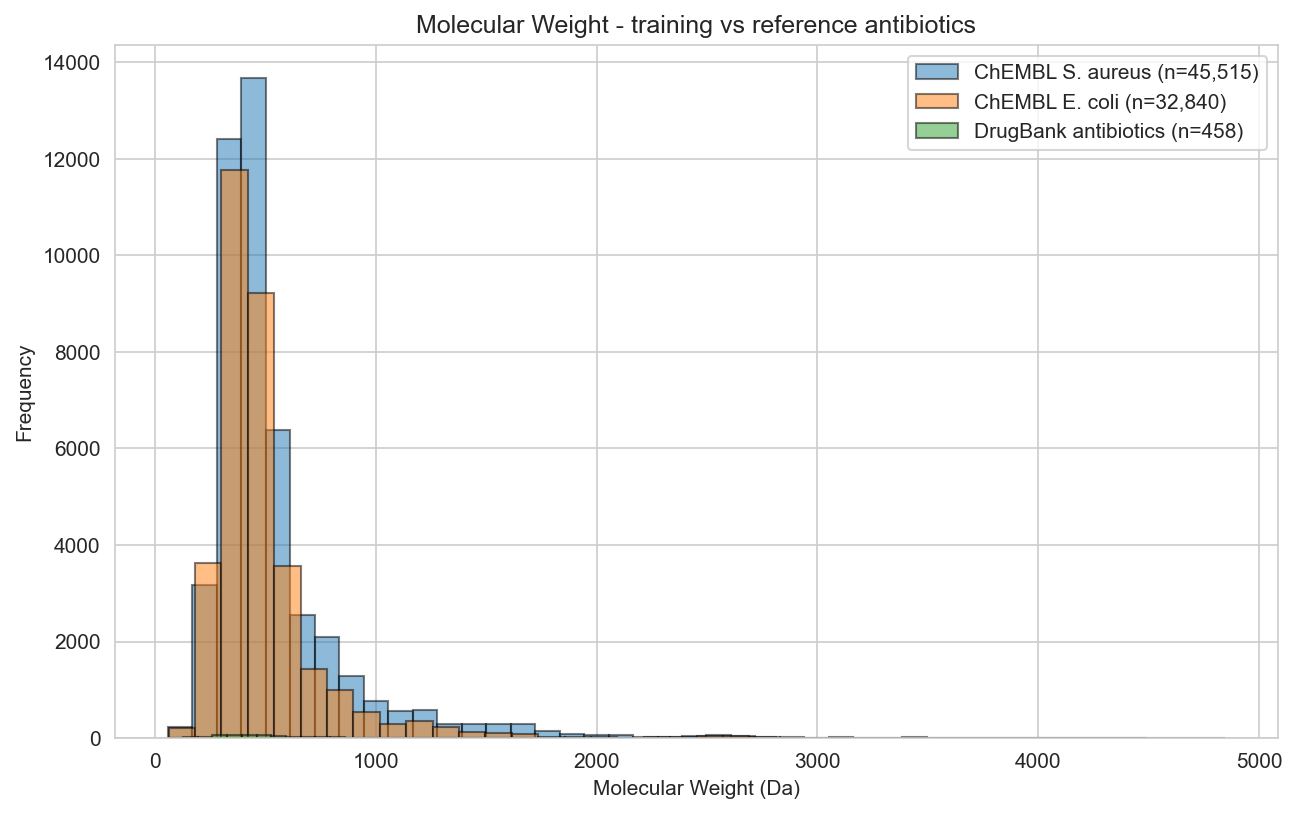

  ChEMBL SA: median 440 Da  5th-95th 259-1188
  ChEMBL EC: median 427 Da  5th-95th 255-976
  DrugBank ab: median 456 Da  5th-95th 198-1267

S. aureus active rate by MW bin:
                 active_rate      n
bin                                
(-0.001, 200.0]     0.134686    542
(200.0, 300.0]      0.219321   4213
(300.0, 400.0]      0.388665  12386
(400.0, 500.0]      0.463549  12167
(500.0, 600.0]      0.499430   6141
(600.0, 800.0]      0.519694   4443
(800.0, 1200.0]     0.551998   3404
(1200.0, inf]       0.599369   2219

E. coli active rate by MW bin:
                 active_rate     n
bin                               
(-0.001, 200.0]     0.118557   388
(200.0, 300.0]      0.152243  3455
(300.0, 400.0]      0.302711  9666
(400.0, 500.0]      0.318586  9109
(500.0, 600.0]      0.325602  4570
(600.0, 800.0]      0.315826  2875
(800.0, 1200.0]     0.382619  1772
(1200.0, inf]       0.327363  1005


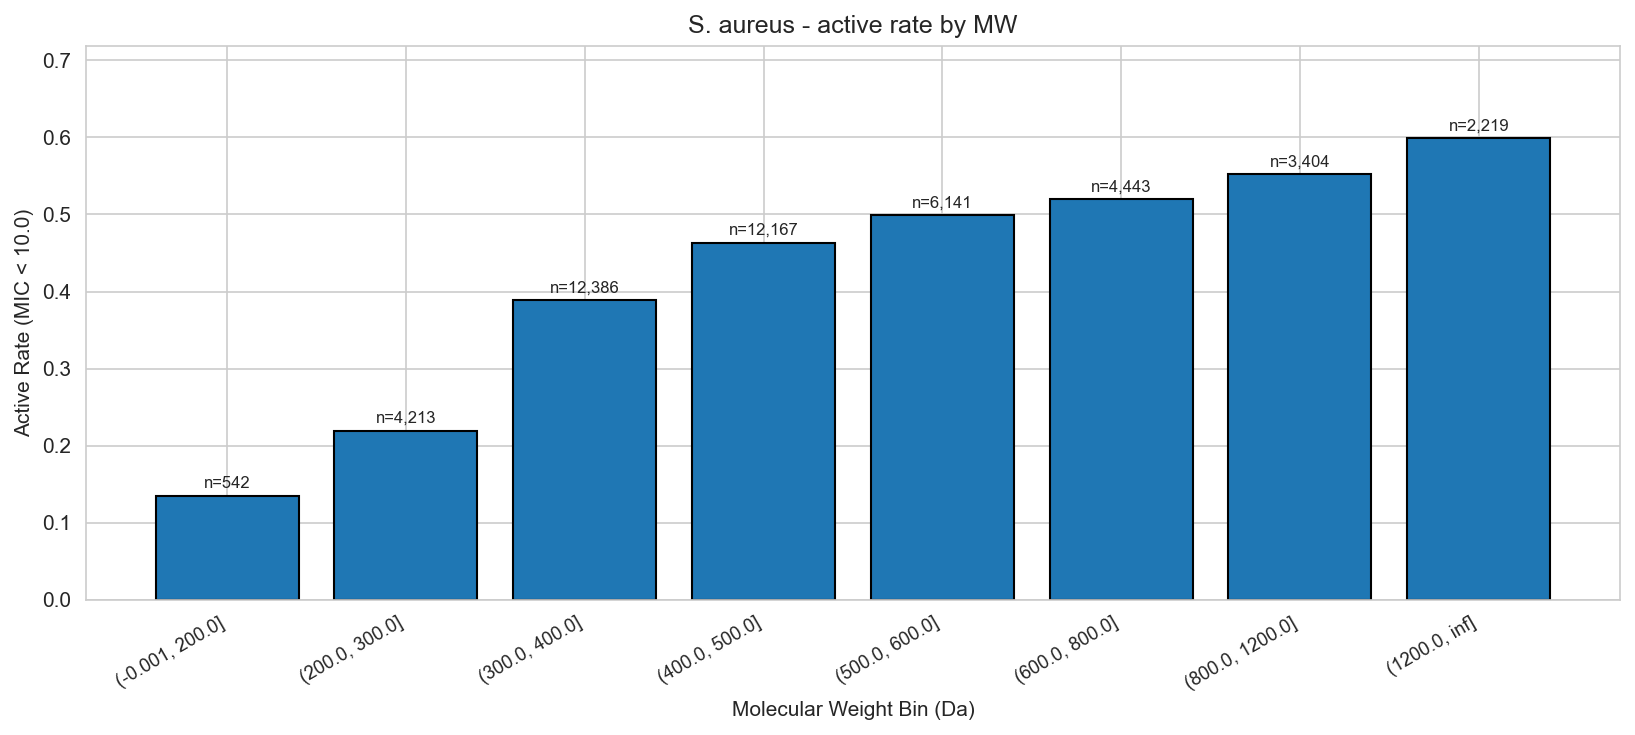

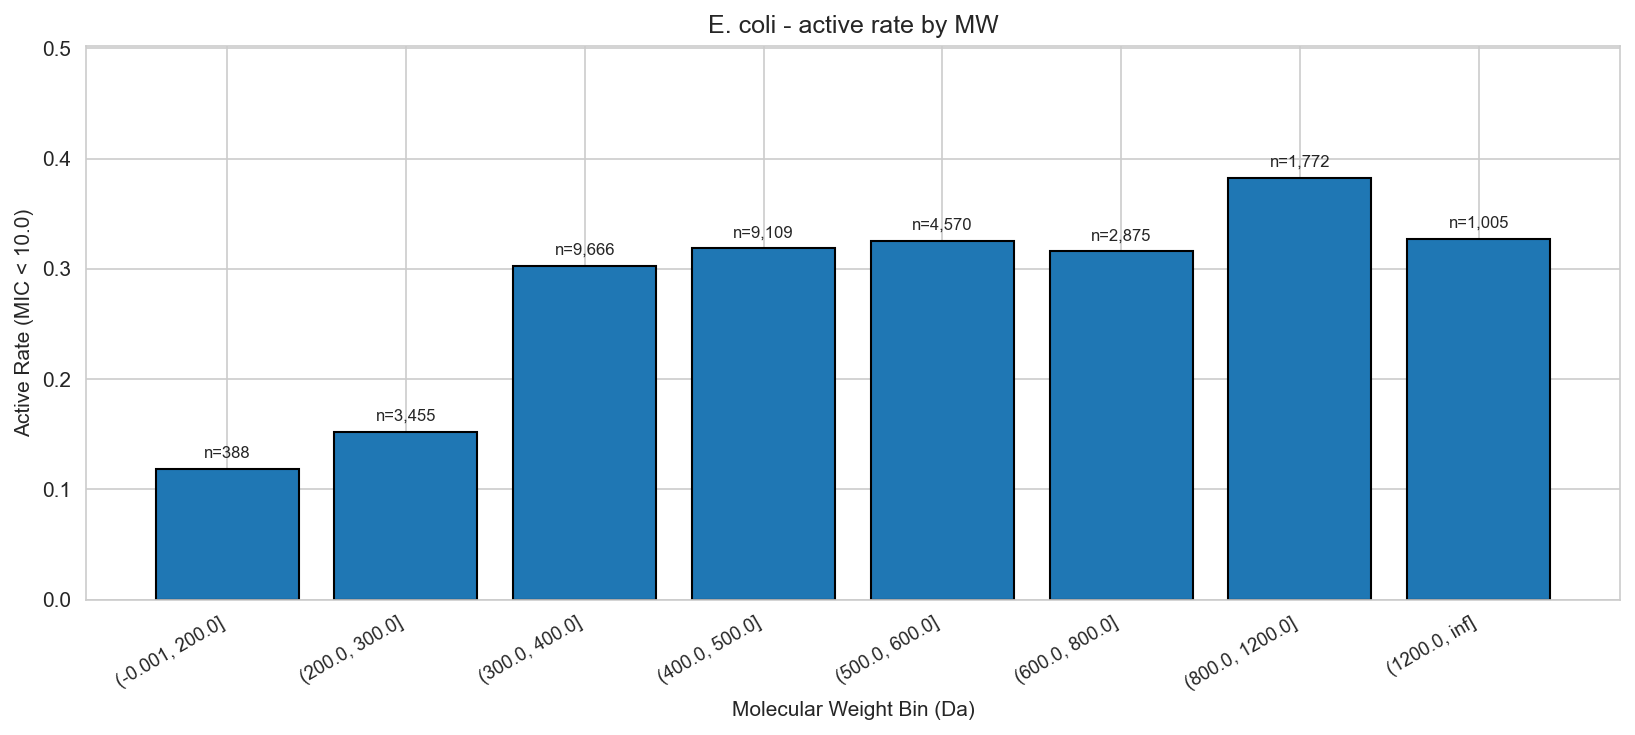

In [20]:
mw_overlay(
    {"ChEMBL S. aureus": sa_props["molecular_weight"],
     "ChEMBL E. coli":   ec_props["molecular_weight"],
     "DrugBank antibiotics": ab_props["molecular_weight"]},
    PLOTS / "mw_train_vs_drugbank.png",
    title="Molecular Weight - training vs reference antibiotics")

for label, col in [("ChEMBL SA", sa_props["molecular_weight"]),
                   ("ChEMBL EC", ec_props["molecular_weight"]),
                   ("DrugBank ab", ab_props["molecular_weight"])]:
    q = col.quantile([0.05, 0.5, 0.95])
    print(f"  {label}: median {q[0.5]:.0f} Da  "
          f"5th-95th {q[0.05]:.0f}-{q[0.95]:.0f}")


MW_BIN_EDGES = [0, 200, 300, 400, 500, 600, 800, 1200, np.inf]

sa_mw = sa_props["molecular_weight"].reindex(sa_unique.values).values
ec_mw = ec_props["molecular_weight"].reindex(ec_unique.values).values

sa_mic_aligned = (df_sa.groupby("canonical_smiles")["mic_value"]
                  .median().reindex(sa_unique.values).values)
ec_mic_aligned = (df_ec.groupby("canonical_smiles")["mic_value"]
                  .median().reindex(ec_unique.values).values)

sa_bins = mw_activity_bins(sa_mic_aligned, sa_mw, MW_BIN_EDGES)
ec_bins = mw_activity_bins(ec_mic_aligned, ec_mw, MW_BIN_EDGES)

print("\nS. aureus active rate by MW bin:")
print(sa_bins.to_string())
print("\nE. coli active rate by MW bin:")
print(ec_bins.to_string())

activity_by_mw_chart(sa_bins, "S. aureus - active rate by MW",
                     PLOTS / "saureus_mw_activity.png")
activity_by_mw_chart(ec_bins, "E. coli - active rate by MW",
                     PLOTS / "ecoli_mw_activity.png")


## Heavy-atom and molecular-weight stats for actives only

In [21]:
def active_size_stats(df, smiles_col="canonical_smiles",
                      mic_col="mic_value", threshold=MIC_THRESHOLD):
    """Heavy-atom and MW percentiles for compounds with median MIC below threshold."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    medians = clean.groupby(smiles_col)["log_mic"].median()
    actives = medians[medians < np.log10(threshold)].index
    rows = []
    for smi in actives:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        rows.append((mol.GetNumHeavyAtoms(),
                     float(Descriptors.MolWt(mol))))
    if not rows:
        return None
    arr = np.array(rows, dtype=np.float64)
    return {"n": len(rows),
            "atoms_q": np.quantile(arr[:, 0], [0.05, 0.5, 0.95]),
            "mw_q": np.quantile(arr[:, 1], [0.05, 0.5, 0.95])}



for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    r = active_size_stats(df)
    if r is None:
        print(f"{label}: no actives")
        continue
    a, m = r["atoms_q"], r["mw_q"]
    print(f"\n{label}: n_actives={r['n']:,}")
    print(f"  heavy atoms: median {int(a[1])}  "
          f"5th-95th {int(a[0])}-{int(a[2])}")
    print(f"  MW (Da):     median {m[1]:.0f}  "
          f"5th-95th {m[0]:.0f}-{m[2]:.0f}")


S. aureus: n_actives=20,673
  heavy atoms: median 33  5th-95th 21-92
  MW (Da):     median 472  5th-95th 301-1313

E. coli: n_actives=10,187
  heavy atoms: median 31  5th-95th 20-73
  MW (Da):     median 444  5th-95th 293-1056


##  In-vocab fraction for actives only

In [22]:
def active_smiles(df, smiles_col="canonical_smiles",
                  mic_col="mic_value", threshold=MIC_THRESHOLD):
    """Canonical SMILES of compounds whose median MIC is below threshold."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    medians = clean.groupby(smiles_col)["log_mic"].median()
    return medians[medians < np.log10(threshold)].index.tolist()


for label, df in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    smiles = active_smiles(df)
    iv, ov, pf, top = atom_vocabulary_split(smiles)
    total = iv + ov + pf
    if total == 0:
        print(f"{label}: no actives")
        continue
    print(f"\n{label}: n_actives={total:,}")
    print(f"  in RL vocab (C,N,O,S,F,Cl only): "
          f"{iv:>6,}  ({iv / total:.1%})")
    print(f"  contains out-of-vocab atom:      "
          f"{ov:>6,}  ({ov / total:.1%})")
    if not top.empty:
        print(f"  most common out-of-vocab atoms (top 5):")
        for atom, n in top.head(5).items():
            print(f"    {atom:<4} {n:>6,}")


S. aureus: n_actives=20,673
  in RL vocab (C,N,O,S,F,Cl only): 18,576  (89.9%)
  contains out-of-vocab atom:       2,097  (10.1%)
  most common out-of-vocab atoms (top 5):
    Br    1,251
    I       308
    Na      258
    P       209
    B        67

E. coli: n_actives=10,187
  in RL vocab (C,N,O,S,F,Cl only):  9,038  (88.7%)
  contains out-of-vocab atom:       1,149  (11.3%)
  most common out-of-vocab atoms (top 5):
    Br      569
    Na      280
    P       113
    B        79
    I        53


## Scaffold split sanity check: zero shared scaffolds

In [23]:
folds = joint_folds([df_sa, df_ec])
organisms = [("S. aureus", df_sa), ("E. coli", df_ec)]
names = ["train", "val", "test"]


def fold_smiles(df, name):
    col = df["canonical_smiles"]
    return col[col.map(folds) == name]


def fold_positions(df, name):
    return np.flatnonzero((df["canonical_smiles"].map(folds) == name).to_numpy())


scaf = {(org, name): scaffold_set(fold_smiles(df, name))
        for org, df in organisms for name in names}

for org, df in organisms:
    sizes = df["canonical_smiles"].map(folds).value_counts()
    print(f"{org} split sizes: train={sizes.get('train', 0):,}  "
          f"val={sizes.get('val', 0):,}  test={sizes.get('test', 0):,}")

worst = max((len(scaf[a] & scaf[b])
             for a in scaf for b in scaf if a[1] < b[1]), default=0)
print(f"Max scaffolds shared across differing folds "
      f"(within and cross organism): {worst}")

sa_tr, sa_te = fold_positions(df_sa, "train"), fold_positions(df_sa, "test")
ec_tr, ec_te = fold_positions(df_ec, "train"), fold_positions(df_ec, "test")


S. aureus split sizes: train=54,595  val=7,501  test=6,415
E. coli split sizes: train=34,658  val=5,302  test=4,171
Max scaffolds shared across differing folds (within and cross organism): 0


## Test-vs-train chemical similarity: per-organism and combined overlay

  S. aureus: median 0.686  5th-95th 0.356-0.966  >=0.6: 65.5%  >=0.4: 90.3%
  E. coli: median 0.659  5th-95th 0.333-0.966  >=0.6: 60.6%  >=0.4: 87.2%


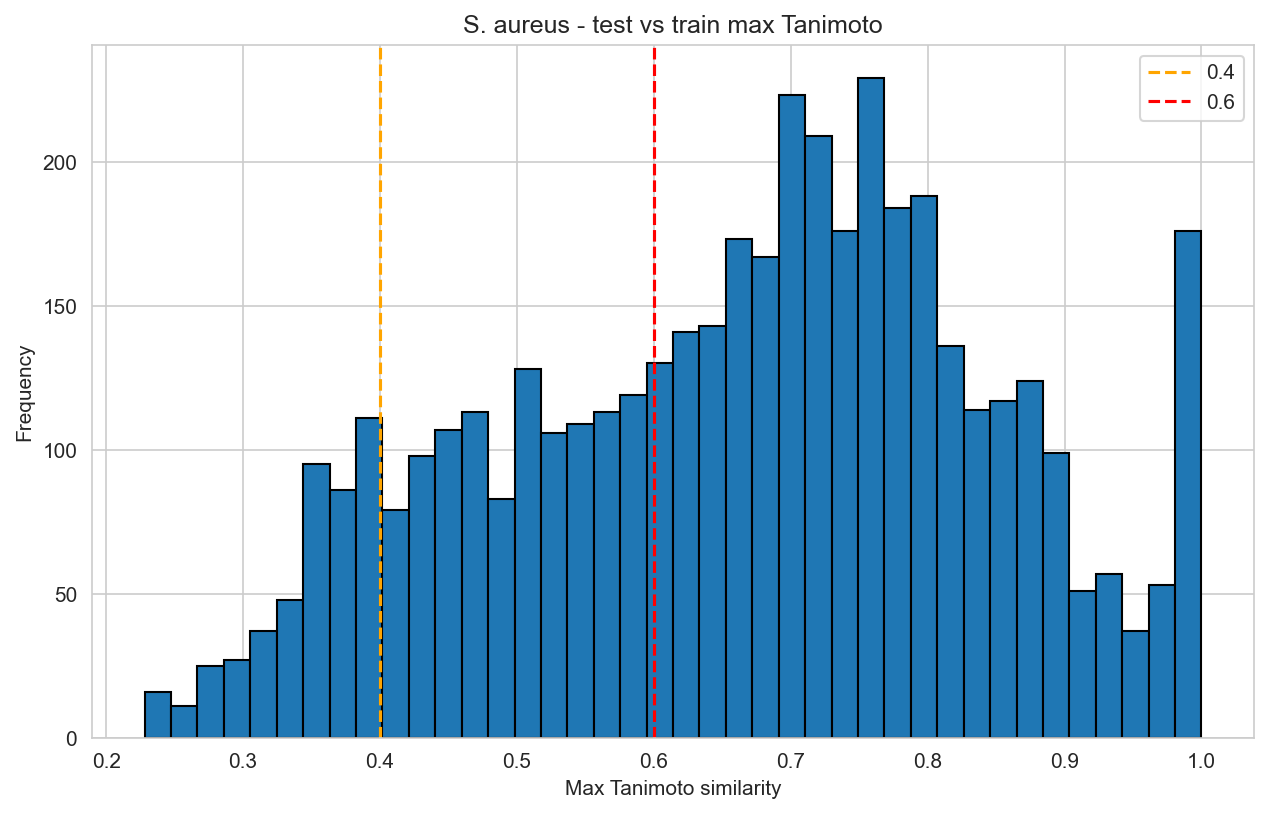

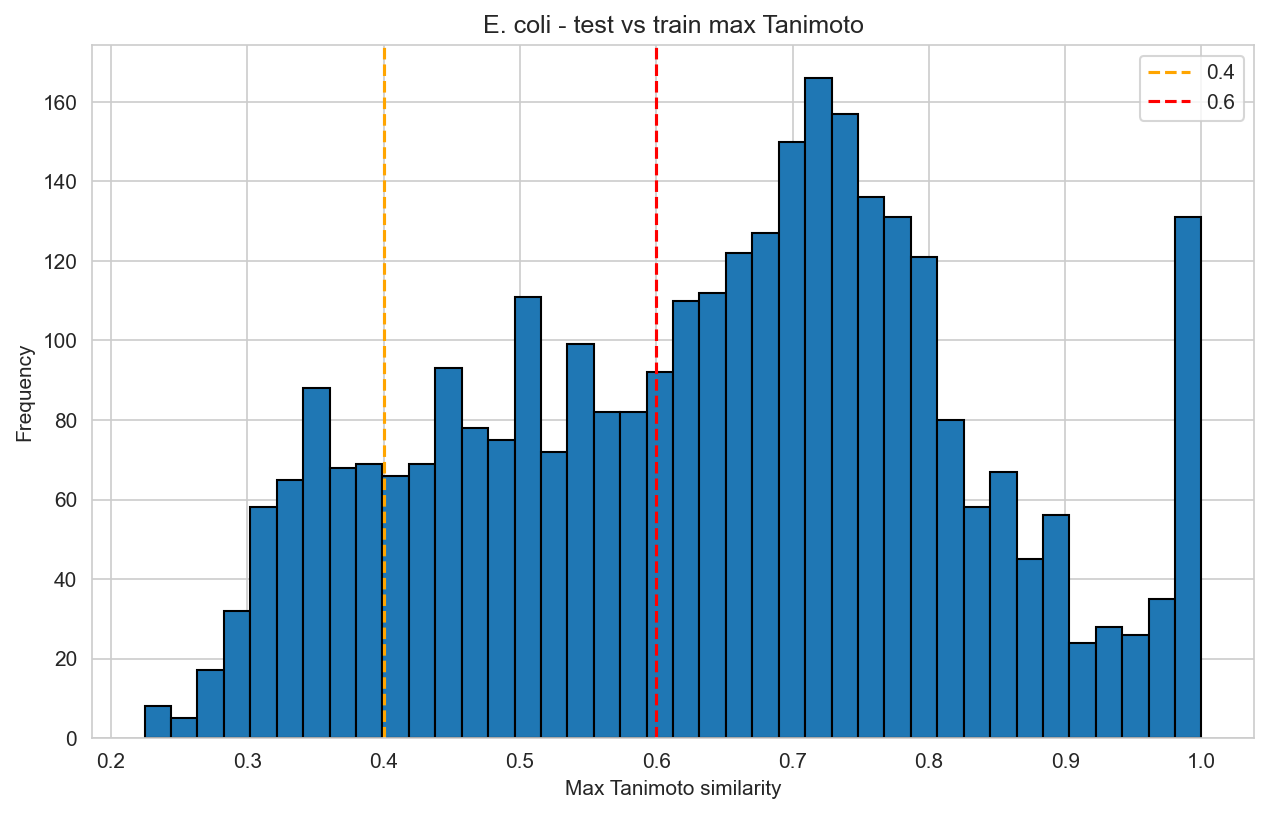

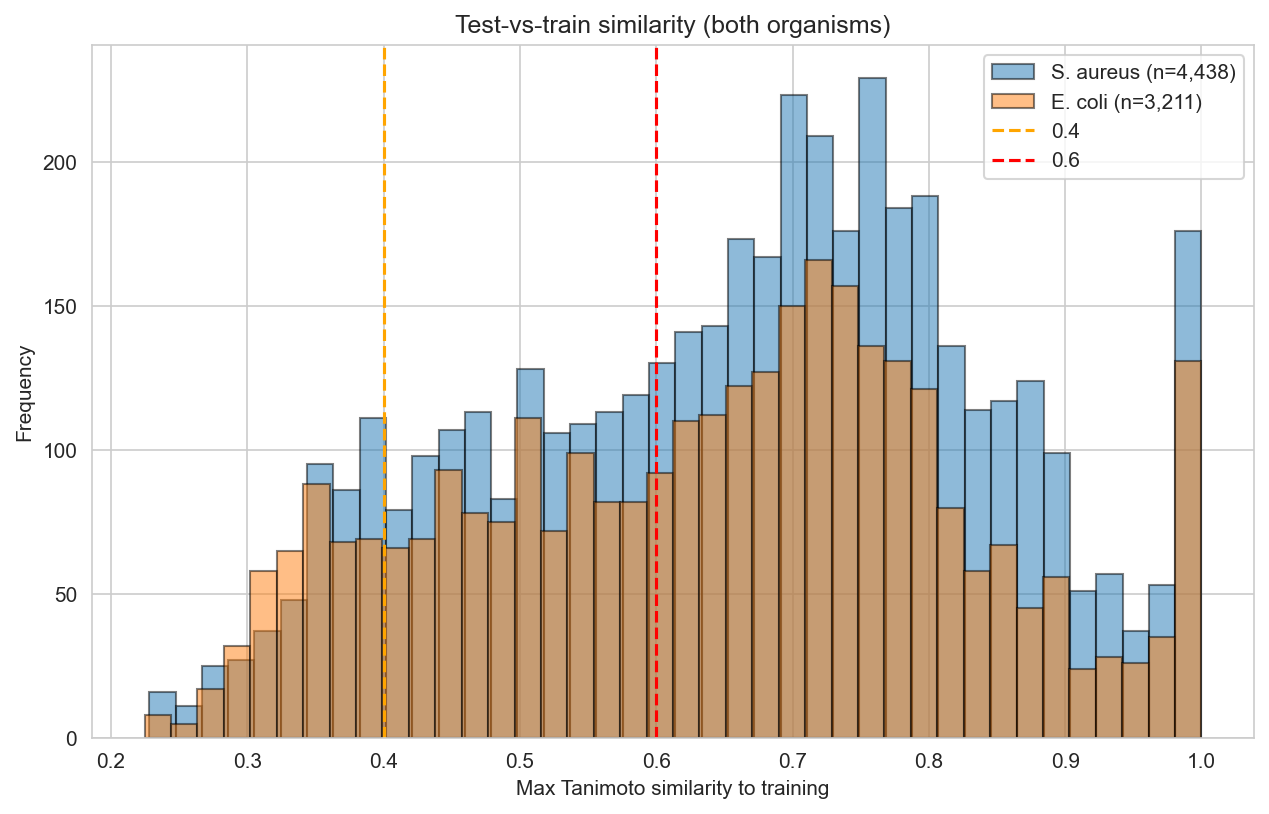

In [24]:
sa_train_fps = fold_unique_fps(df_sa, sa_tr)
sa_test_fps = fold_unique_fps(df_sa, sa_te)
ec_train_fps = fold_unique_fps(df_ec, ec_tr)
ec_test_fps = fold_unique_fps(df_ec, ec_te)

sa_test_sim = nearest_similarity(sa_test_fps, sa_train_fps)
ec_test_sim = nearest_similarity(ec_test_fps, ec_train_fps)

for label, sim in [("S. aureus", sa_test_sim), ("E. coli", ec_test_sim)]:
    q = np.quantile(sim, [0.05, 0.5, 0.95])
    print(f"  {label}: median {q[1]:.3f}  5th-95th {q[0]:.3f}-{q[2]:.3f}  "
          f">=0.6: {(sim >= 0.6).mean():.1%}  "
          f">=0.4: {(sim >= 0.4).mean():.1%}")

similarity_density(sa_test_sim, PLOTS / "saureus_test_train_sim.png",
                   title="S. aureus - test vs train max Tanimoto")
similarity_density(ec_test_sim, PLOTS / "ecoli_test_train_sim.png",
                   title="E. coli - test vs train max Tanimoto")

similarity_overlay(
    {"S. aureus": sa_test_sim, "E. coli": ec_test_sim},
    PLOTS / "test_train_sim_overlay.png",
    title="Test-vs-train similarity (both organisms)")


## SMILES length distribution

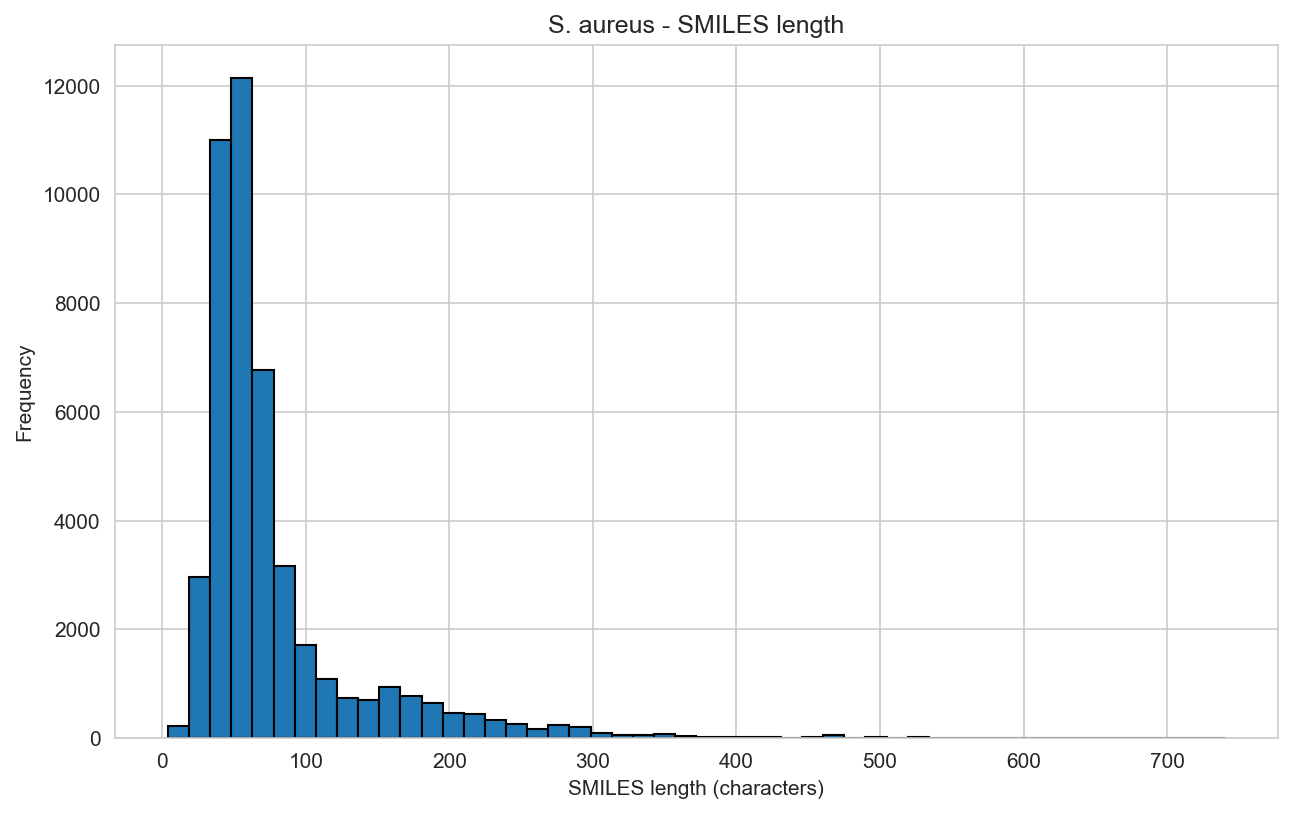

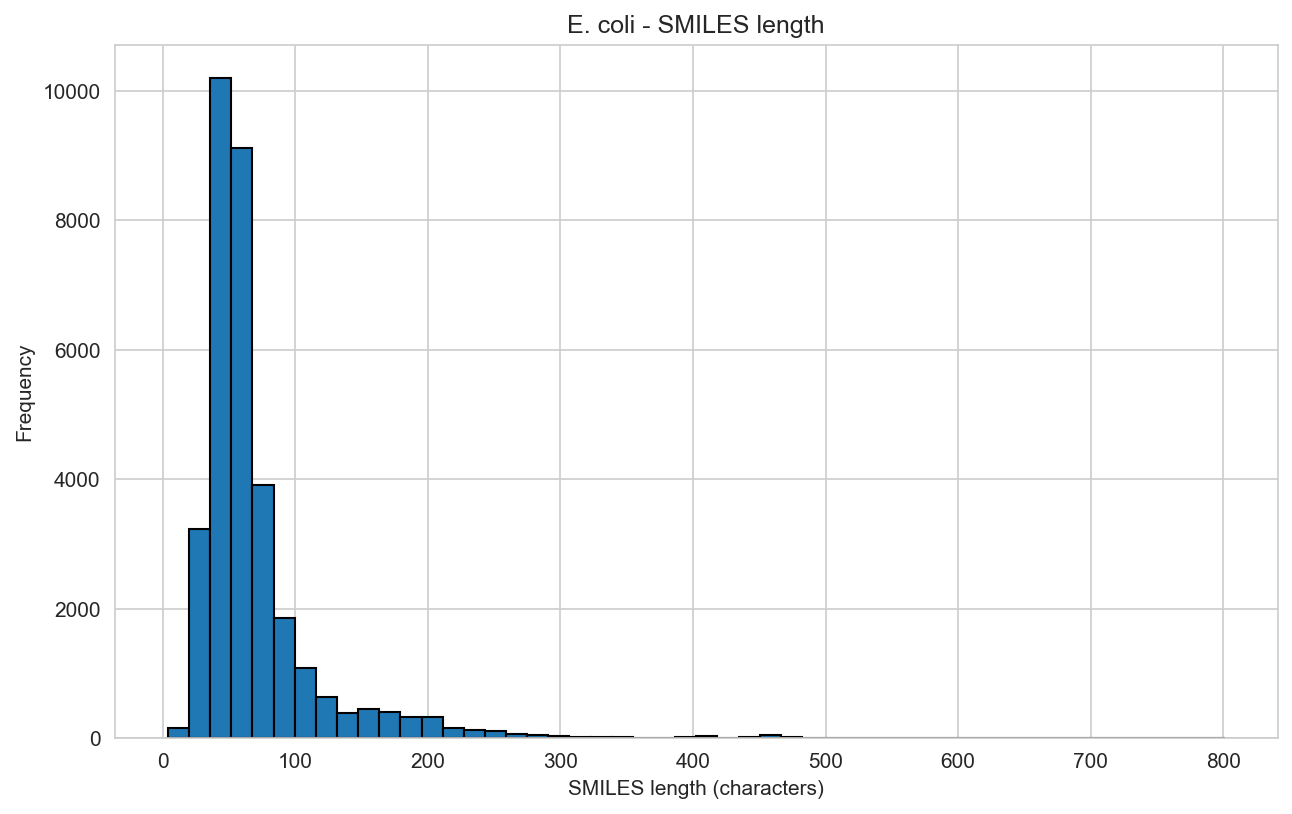

  S. aureus: median 58 chars  5th-95th 31-207  max 740
  E. coli: median 56 chars  5th-95th 30-170  max 801


In [25]:
length_histogram(sa_unique, PLOTS / "saureus_smiles_length.png",
                 title="S. aureus - SMILES length")
length_histogram(ec_unique, PLOTS / "ecoli_smiles_length.png",
                 title="E. coli - SMILES length")

for label, s in [("S. aureus", sa_unique), ("E. coli", ec_unique)]:
    lens = s.dropna().astype(str).str.len()
    q = lens.quantile([0.05, 0.5, 0.95])
    print(f"  {label}: median {int(q[0.5])} chars  "
          f"5th-95th {int(q[0.05])}-{int(q[0.95])}  "
          f"max {int(lens.max())}")


## Replicate noise floor


In [26]:
print("Log-MIC replicate noise floor (per-compound std, median):")
for name, frame in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    stats = log_replicate_variance(frame, "canonical_smiles", "mic_value")
    floor = float("nan") if stats.empty else float(stats["std"].median())
    n = 0 if stats.empty else len(stats)
    print(f"  {name:<10} {floor:.3f}  (n_replicated={n:,})")


Log-MIC replicate noise floor (per-compound std, median):
  S. aureus  0.426  (n_replicated=13,633)
  E. coli    0.624  (n_replicated=5,311)


## Salt leakage estimate

In [27]:
def parent_canonical(smiles):
    """Largest fragment of a multi-fragment SMILES, canonicalized."""
    if "." not in smiles:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    frags = Chem.GetMolFrags(mol, asMols=True)
    if not frags:
        return None
    largest = max(frags, key=lambda m: m.GetNumHeavyAtoms())
    return Chem.MolToSmiles(largest)


def salt_leakage(smiles_series):
    """Count salt SMILES whose parent fragment also appears as a non-salt."""
    unique = smiles_series.dropna().drop_duplicates()
    salt_mask = unique.str.contains(r"\.", regex=True, na=False)
    salts = unique[salt_mask]
    non_salts = set(unique[~salt_mask])
    parents = salts.map(parent_canonical).dropna()
    leaks = parents[parents.isin(non_salts)]
    return {
        "n_unique": len(unique),
        "n_salts": int(salt_mask.sum()),
        "n_parents_resolved": len(parents),
        "n_leaks": len(leaks),
        "leak_rate_of_salts": float(len(leaks) / max(len(parents), 1)),
        "leak_rate_of_total": float(len(leaks) / max(len(unique), 1)),
    }


for label, smiles in [("S. aureus", df_sa["canonical_smiles"]),
                      ("E. coli",   df_ec["canonical_smiles"])]:
    r = salt_leakage(smiles)
    print(f"{label}:")
    print(f"  unique compounds:                 {r['n_unique']:>7,}")
    print(f"  contain '.': salt forms:          {r['n_salts']:>7,}  "
          f"({r['n_salts'] / r['n_unique']:.1%} of unique)")
    print(f"  parents canonicalized:            {r['n_parents_resolved']:>7,}")
    print(f"  parent matches a non-salt entry:  {r['n_leaks']:>7,}")
    print(f"  leak rate among salts:            "
          f"{r['leak_rate_of_salts']:.1%}")
    print(f"  leak rate over full dataset:      "
          f"{r['leak_rate_of_total']:.1%}")
    print()


S. aureus:
  unique compounds:                  45,515
  contain '.': salt forms:            3,708  (8.1% of unique)
  parents canonicalized:              3,708
  parent matches a non-salt entry:      203
  leak rate among salts:            5.5%
  leak rate over full dataset:      0.4%

E. coli:
  unique compounds:                  32,840
  contain '.': salt forms:            3,034  (9.2% of unique)
  parents canonicalized:              3,034
  parent matches a non-salt entry:      157
  leak rate among salts:            5.2%
  leak rate over full dataset:      0.5%



## Noise-ceiling AUROC

In [28]:
def noise_ceiling_auroc(df, smiles_col="canonical_smiles",
                        mic_col="mic_value", threshold=MIC_THRESHOLD):
    """Empirical AUROC ceiling: median predictions vs noisy replicate labels."""
    clean = df[[smiles_col, mic_col]].dropna()
    clean = clean[clean[mic_col] > 0].copy()
    clean["log_mic"] = np.log10(clean[mic_col])
    medians = clean.groupby(smiles_col)["log_mic"].transform("median")
    clean["replicate_label"] = (clean[mic_col] < threshold).astype(int)
    clean["median_score"] = -medians
    if clean["replicate_label"].nunique() < 2:
        return {"n": 0, "ceiling_auroc": 0.0,
                "n_replicated": 0, "ceiling_auroc_replicated": 0.0}
    full = float(roc_auc_score(
        clean["replicate_label"], clean["median_score"]))
    sizes = clean.groupby(smiles_col)[mic_col].transform("size")
    rep = clean[sizes > 1]
    rep_auroc = (float(roc_auc_score(
        rep["replicate_label"], rep["median_score"]))
        if rep["replicate_label"].nunique() == 2 else 0.0)
    return {
        "n": int(len(clean)),
        "ceiling_auroc": full,
        "n_replicated": int(len(rep)),
        "ceiling_auroc_replicated": rep_auroc,
    }


print("AUROC noise ceiling (oracle median log-MIC vs noisy labels):")
for name, frame in [("S. aureus", df_sa), ("E. coli", df_ec)]:
    r = noise_ceiling_auroc(frame)
    print(f"  {name:<10} full={r['ceiling_auroc']:.3f}  "
          f"replicated={r['ceiling_auroc_replicated']:.3f}  "
          f"(n_repl={r['n_replicated']:,})")


AUROC noise ceiling (oracle median log-MIC vs noisy labels):
  S. aureus  full=0.955  replicated=0.891  (n_repl=36,614)
  E. coli    full=0.961  replicated=0.870  (n_repl=16,597)


## Top potent compounds

In [29]:
sa_top = top_actives(df_sa)
ec_top = top_actives(df_ec)

print("S. aureus - most potent compounds:")
print(sa_top.to_string(index=False))
print("\nE. coli - most potent compounds:")
print(ec_top.to_string(index=False))


S. aureus - most potent compounds:
                                                                                                                                             canonical_smiles  mic_value
                                                                          C[C@@H](O)[C@@]12O[C@]13c1cc(O)c4c(c1N[C@H]2C#C/C=C\C#C[C@H]3O)C(=O)c1c(O)cccc1C4=O   0.000001
                                                                     O=C1c2cccc(O)c2C(=O)c2c3c(cc(O)c21)[C@@]12O[C@@]1([C@H](O)CO)[C@H](C#C/C=C\C#C[C@H]2O)N3   0.000001
                                                                        O=C1c2ccccc2C(=O)c2c3c(cc(O)c21)[C@@]12O[C@@]1([C@H](O)CO)[C@H](C#C/C=C\C#C[C@H]2O)N3   0.000002
CO[C@H]1/C=C/O[C@@]2(C)Oc3c(C)c(O)c4c(O)c(c(/C=N/N5CCN(C)CC5)c(O)c4c3C2=O)NC(=O)/C(C)=C\C=C\[C@H](C)[C@H](O)[C@@H](C)[C@@H](O)[C@@H](C)[C@H](OC(C)=O)[C@@H]1C   0.000006
                                                                                 COc1ccc2ncc(F)c([C@@H](O)[C@H](O)[C@@H]